<a href="https://colab.research.google.com/github/vinicius-mattoso/industrial-rul-predictive-maintenance/blob/main/notebooks/01_rul_eda_and_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RUL Estimation com NASA CMAPSS

Neste notebook vamos construir um projeto de **Remaining Useful Life (RUL)** aplicado à manutenção preditiva de equipamentos.

O objetivo é estimar quantos ciclos de operação ainda restam antes da falha de um motor, usando dados simulados do dataset NASA CMAPSS.

Além da modelagem, vamos incluir uma camada de **guard rails operacionais**, ou seja, regras inspiradas em limites técnicos/manuais de operação para apoiar a decisão de manutenção.

https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data/resource/5224bcd1-ad61-490b-93b9-2817288accb8

In [1]:
!pip install xgboost shap

In [2]:
import os
import zipfile
import urllib.request
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)

sns.set_theme(style="whitegrid")

## 1. Carregamento dos dados

Vamos usar o subconjunto **FD001** do NASA CMAPSS.

Esse subconjunto é um bom ponto de partida porque possui:
- uma condição operacional;
- um modo de falha;
- múltiplos motores;
- sensores medidos ao longo dos ciclos de vida.

Cada motor é observado até a falha. Portanto, o último ciclo disponível de cada motor representa o ponto em que sua vida útil chegou ao fim.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt
Saving train_FD001.txt to train_FD001.txt


In [4]:
index_columns = ["unit_number", "time_in_cycles"]

setting_columns = [f"setting_{i}" for i in range(1, 4)]

sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

columns = index_columns + setting_columns + sensor_columns

print("Total de colunas:", len(columns))
columns

Total de colunas: 26


['unit_number',
 'time_in_cycles',
 'setting_1',
 'setting_2',
 'setting_3',
 'sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

In [5]:
train_df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

test_df = pd.read_csv(
    "test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

rul_test = pd.read_csv(
    "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["true_rul"]
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL test shape:", rul_test.shape)

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL test shape: (100, 1)


# 2. Exploratory Data Analysis (EDA)

Antes da modelagem, precisamos entender:
- o comportamento operacional dos motores;
- a distribuição dos sensores;
- possíveis padrões de degradação;
- variabilidade operacional;
- sensores com potencial informativo.

Essa etapa é fundamental em projetos industriais, pois o entendimento físico e operacional dos dados costuma ser tão importante quanto o próprio modelo de Machine Learning.

In [6]:
train_df.head()

,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
test_df.head()

,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [8]:
rul_test.head()

,true_rul
0,112
1,98
2,69
3,82
4,91


In [9]:
print("Motores no treino:", train_df["unit_number"].nunique())
print("Motores no teste:", test_df["unit_number"].nunique())

# print("\nCiclos no treino:")
# display(train_df.groupby("unit_number")["time_in_cycles"].max().describe())

# print("\nCiclos no teste:")
# display(test_df.groupby("unit_number")["time_in_cycles"].max().describe())

Motores no treino: 100
Motores no teste: 100


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   setting_1       20631 non-null  float64
 3   setting_2       20631 non-null  float64
 4   setting_3       20631 non-null  float64
 5   sensor_1        20631 non-null  float64
 6   sensor_2        20631 non-null  float64
 7   sensor_3        20631 non-null  float64
 8   sensor_4        20631 non-null  float64
 9   sensor_5        20631 non-null  float64
 10  sensor_6        20631 non-null  float64
 11  sensor_7        20631 non-null  float64
 12  sensor_8        20631 non-null  float64
 13  sensor_9        20631 non-null  float64
 14  sensor_10       20631 non-null  float64
 15  sensor_11       20631 non-null  float64
 16  sensor_12       20631 non-null  float64
 17  sensor_13       20631 non-null 

In [11]:
train_df.describe()

,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.300000e+00,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,0.001389,0.885092,0.070985,22.082880,4.660829e-13,0.267087,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.300000e+00,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.300000e+00,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.300000e+00,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.300000e+00,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.300000e+00,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


## Vida útil observada por motor

Cada motor possui uma trajetória operacional diferente até a falha.

Essa variabilidade é importante porque o modelo precisa aprender padrões gerais de degradação e não apenas memorizar ciclos específicos.

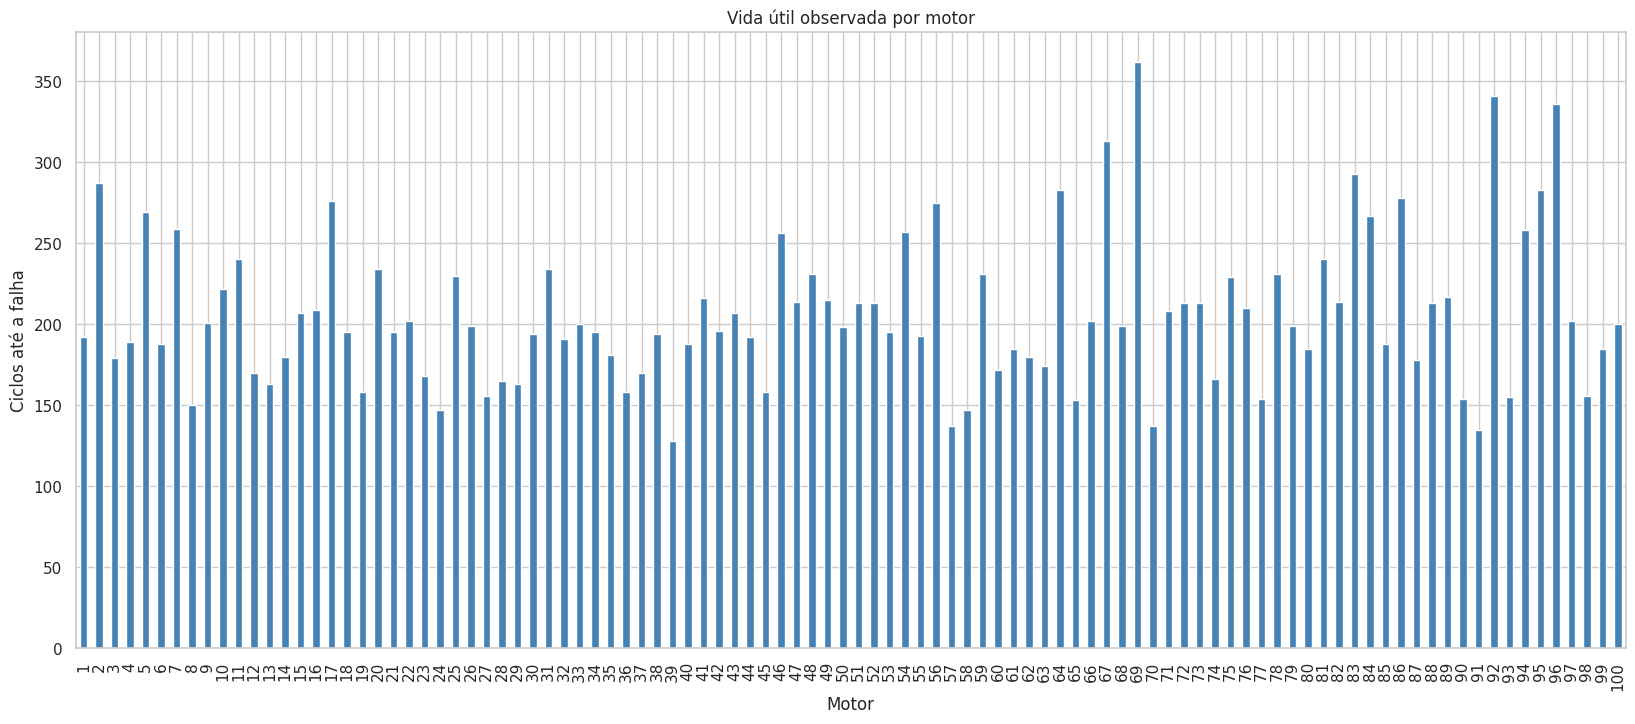

In [12]:
life_per_engine = (
    train_df
    .groupby("unit_number")["time_in_cycles"]
    .max()
)

plt.figure(figsize=(20, 8))

life_per_engine.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Vida útil observada por motor")
plt.xlabel("Motor")
plt.ylabel("Ciclos até a falha")

plt.show()

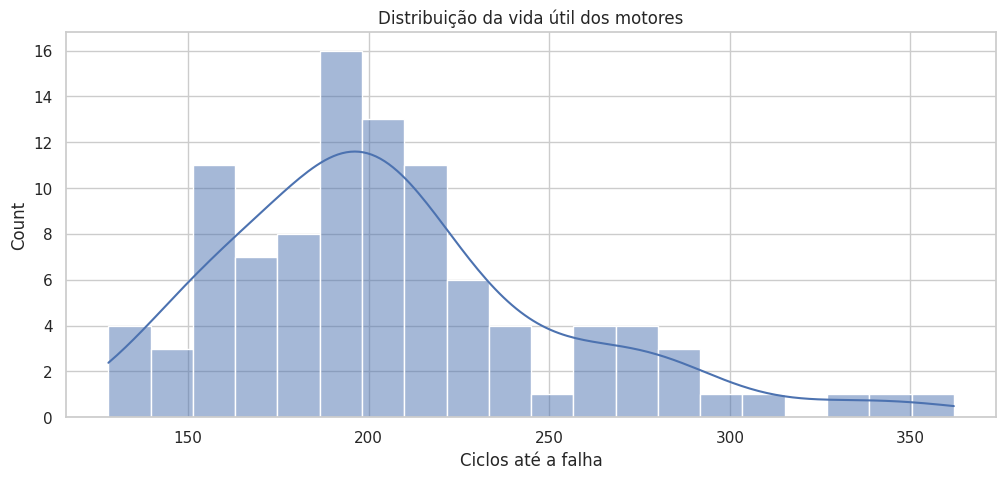

In [13]:
plt.figure(figsize=(12, 5))

sns.histplot(
    life_per_engine,
    bins=20,
    kde=True
)

plt.title("Distribuição da vida útil dos motores")
plt.xlabel("Ciclos até a falha")

plt.show()

## Qualidade dos dados

Em ambientes industriais reais é comum encontrarmos:
- falhas de telemetria;
- sensores ausentes;
- perda de comunicação;
- leituras inconsistentes.

Vamos validar rapidamente a integridade dos dados.

In [14]:
missing_values = train_df.isnull().sum()

missing_values[missing_values > 0]

,0


## Distribuição dos sensores

Vamos analisar a distribuição de alguns sensores para entender:
- dispersão;
- presença de outliers;
- comportamento operacional.

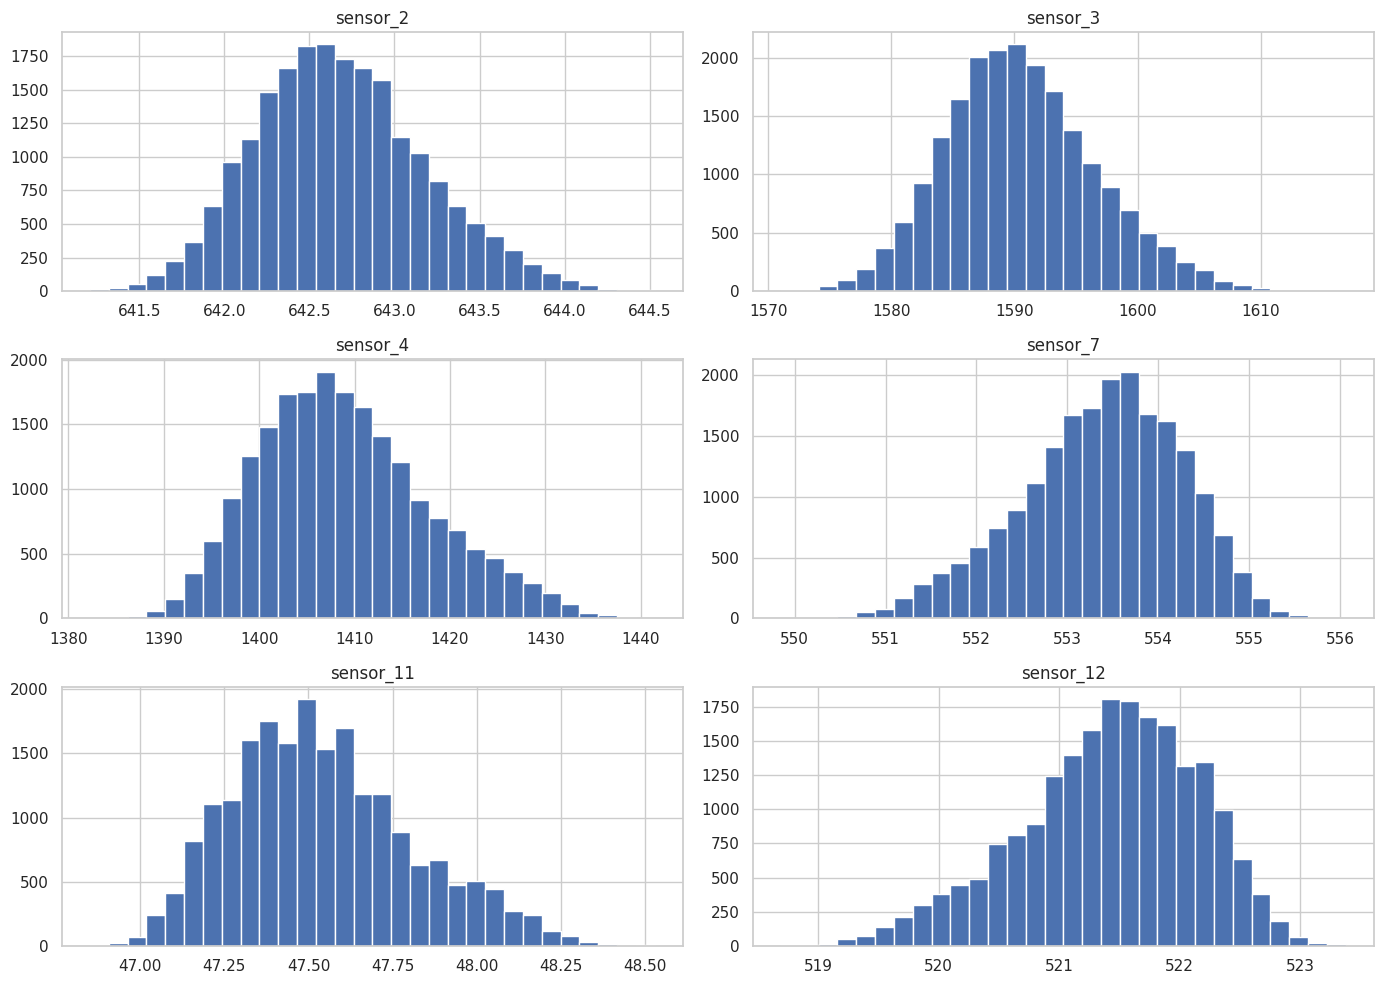

In [15]:
selected_sensors = [
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_7",
    "sensor_11",
    "sensor_12"
]

train_df[selected_sensors].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

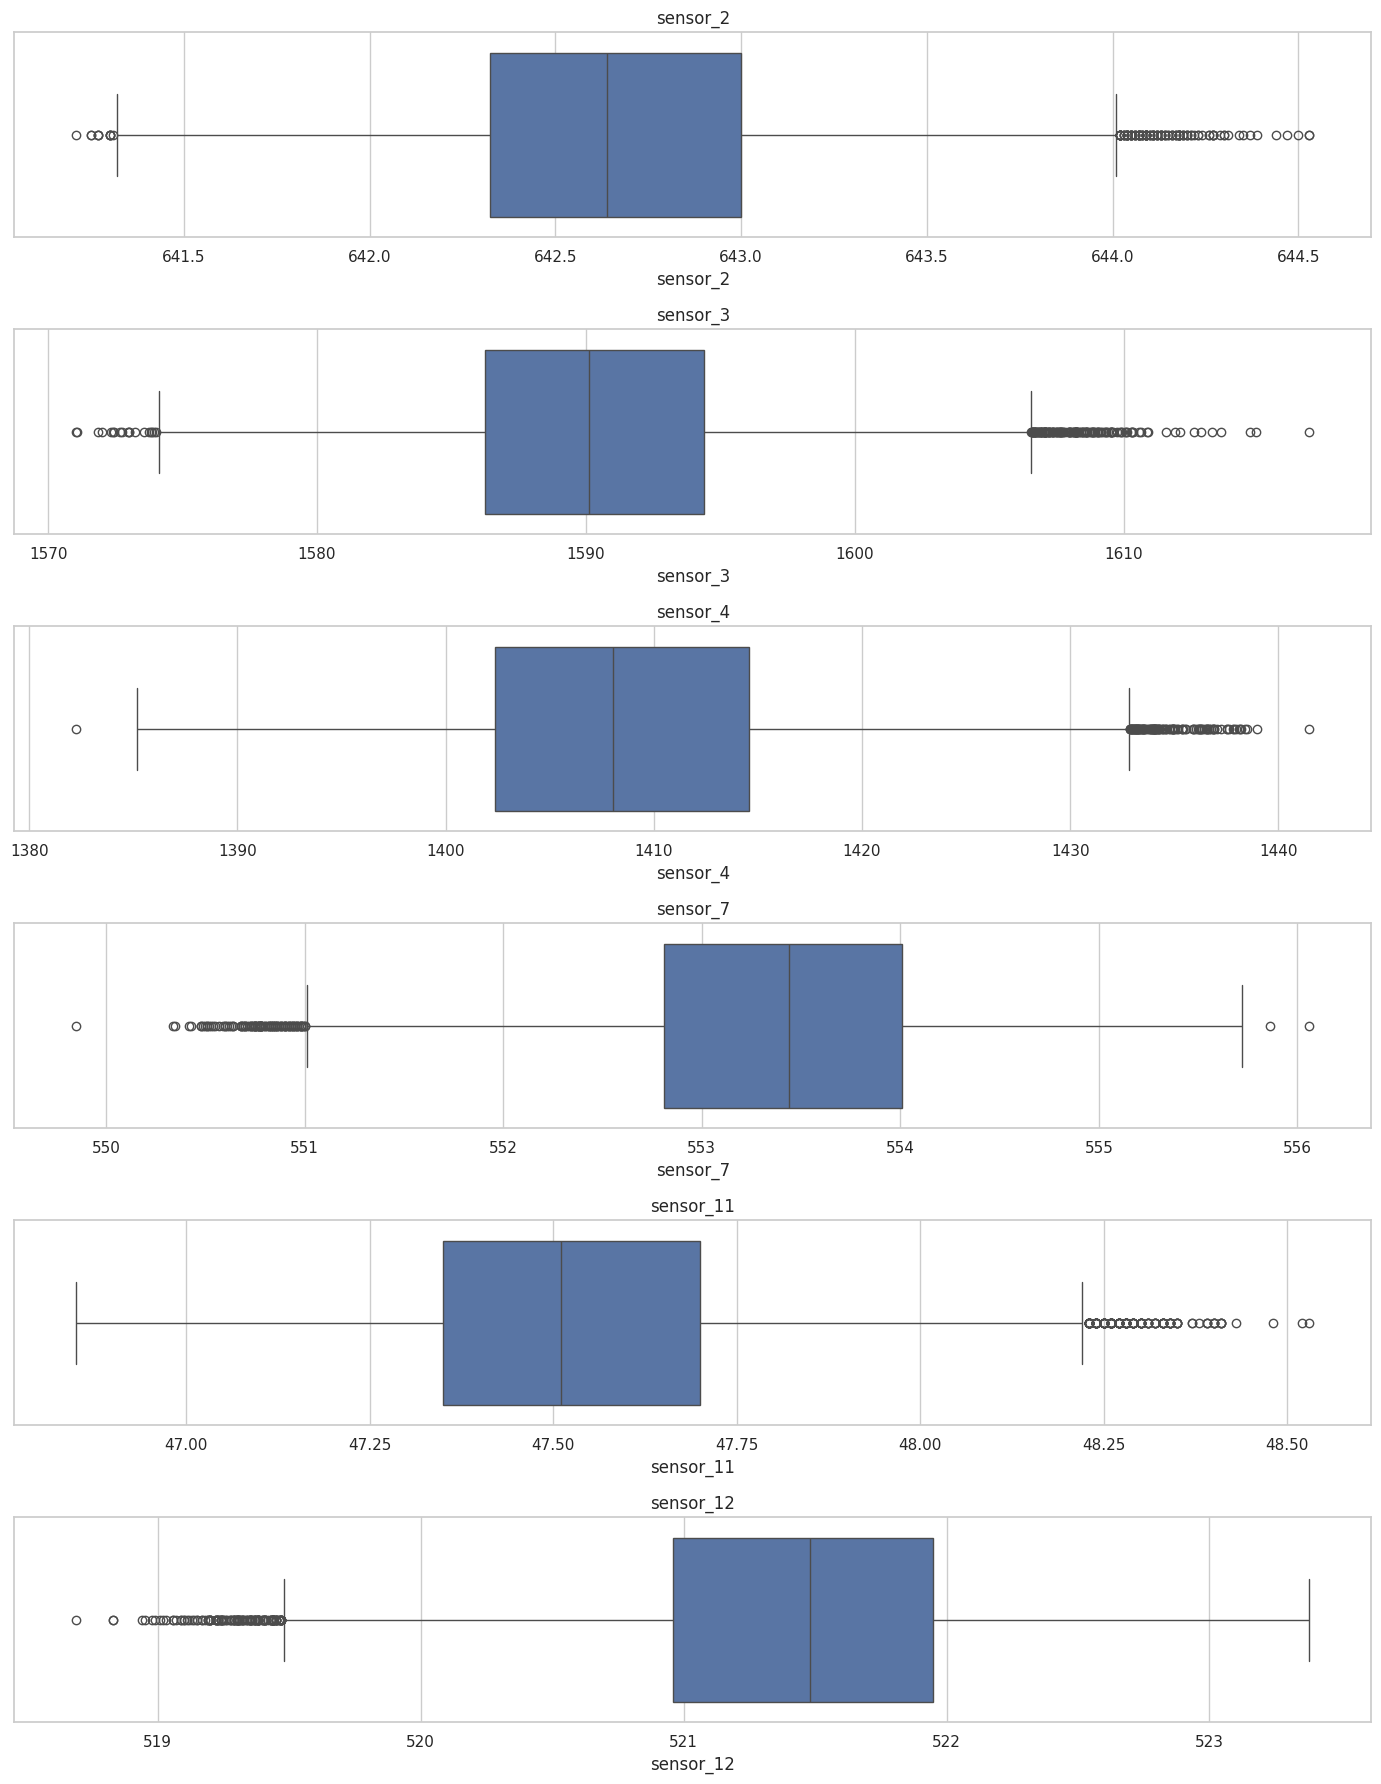

In [16]:
fig, axes = plt.subplots(
    len(selected_sensors),
    1,
    figsize=(14, 18)
)

for i, sensor in enumerate(selected_sensors):

    sns.boxplot(
        x=train_df[sensor],
        ax=axes[i]
    )

    axes[i].set_title(sensor)

plt.tight_layout()
plt.show()

## Correlação entre sensores

Sensores altamente correlacionados podem:
- representar redundância operacional;
- indicar variáveis fisicamente relacionadas;
- impactar feature selection.

In [17]:
correlation_matrix = train_df[sensor_columns].corr()

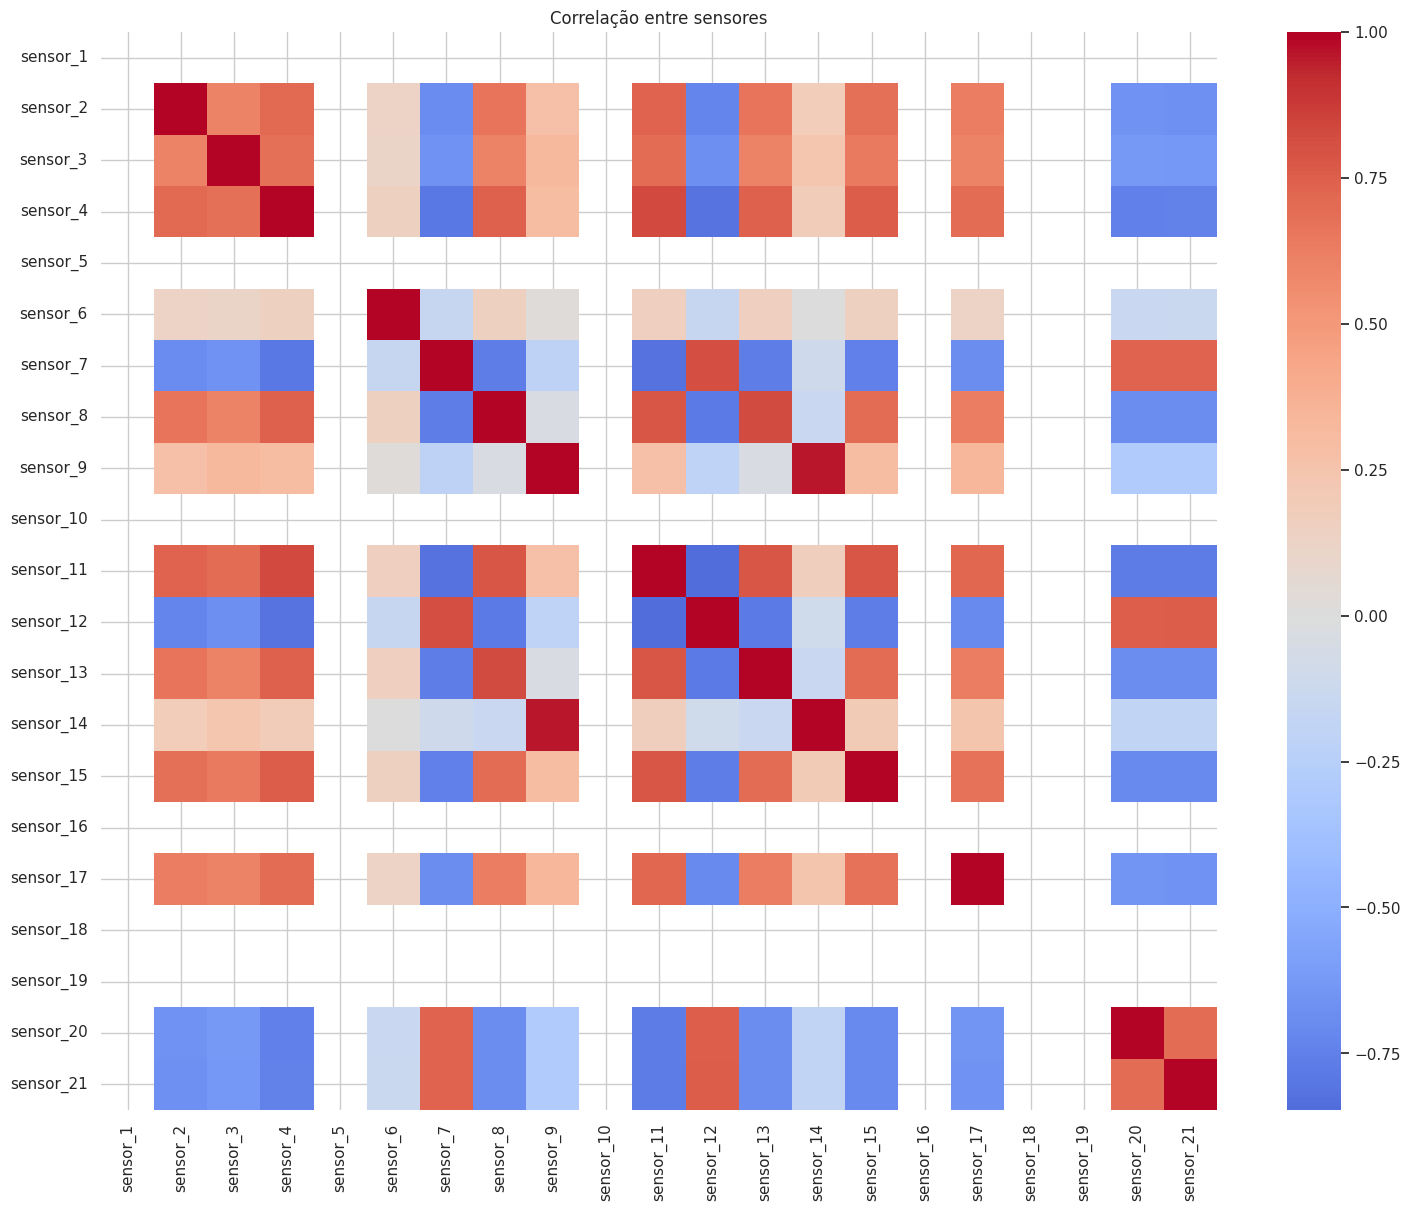

In [18]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlação entre sensores")

plt.show()

## Sensores com baixa variabilidade

Sensores praticamente constantes tendem a possuir baixa capacidade preditiva.

Esse comportamento é muito comum em sistemas industriais reais, onde parte da instrumentação opera em regime quase estacionário.

In [19]:
sensor_variance = (
    train_df[sensor_columns]
    .var()
    .sort_values()
)

sensor_variance

,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,2.422479e-28
sensor_10,2.172333e-25
sensor_5,1.152399e-23
sensor_1,4.273435e-21
sensor_6,1.929279e-06
sensor_15,1.406628e-03
sensor_8,5.038938e-03
sensor_13,5.172330e-03


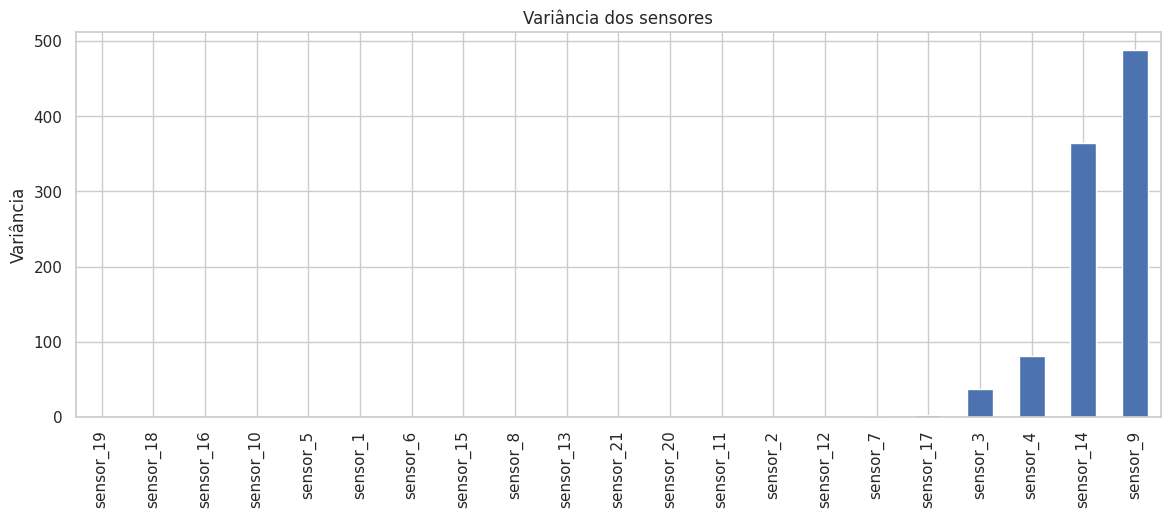

In [20]:
plt.figure(figsize=(14, 5))

sensor_variance.plot(kind="bar")

plt.title("Variância dos sensores")
plt.ylabel("Variância")

plt.show()

## Trajetória operacional dos sensores

Agora vamos observar como os sensores evoluem ao longo dos ciclos de operação.

Essa análise é importante para identificar:
- tendências de degradação;
- aumento de variabilidade;
- mudanças operacionais próximas da falha.

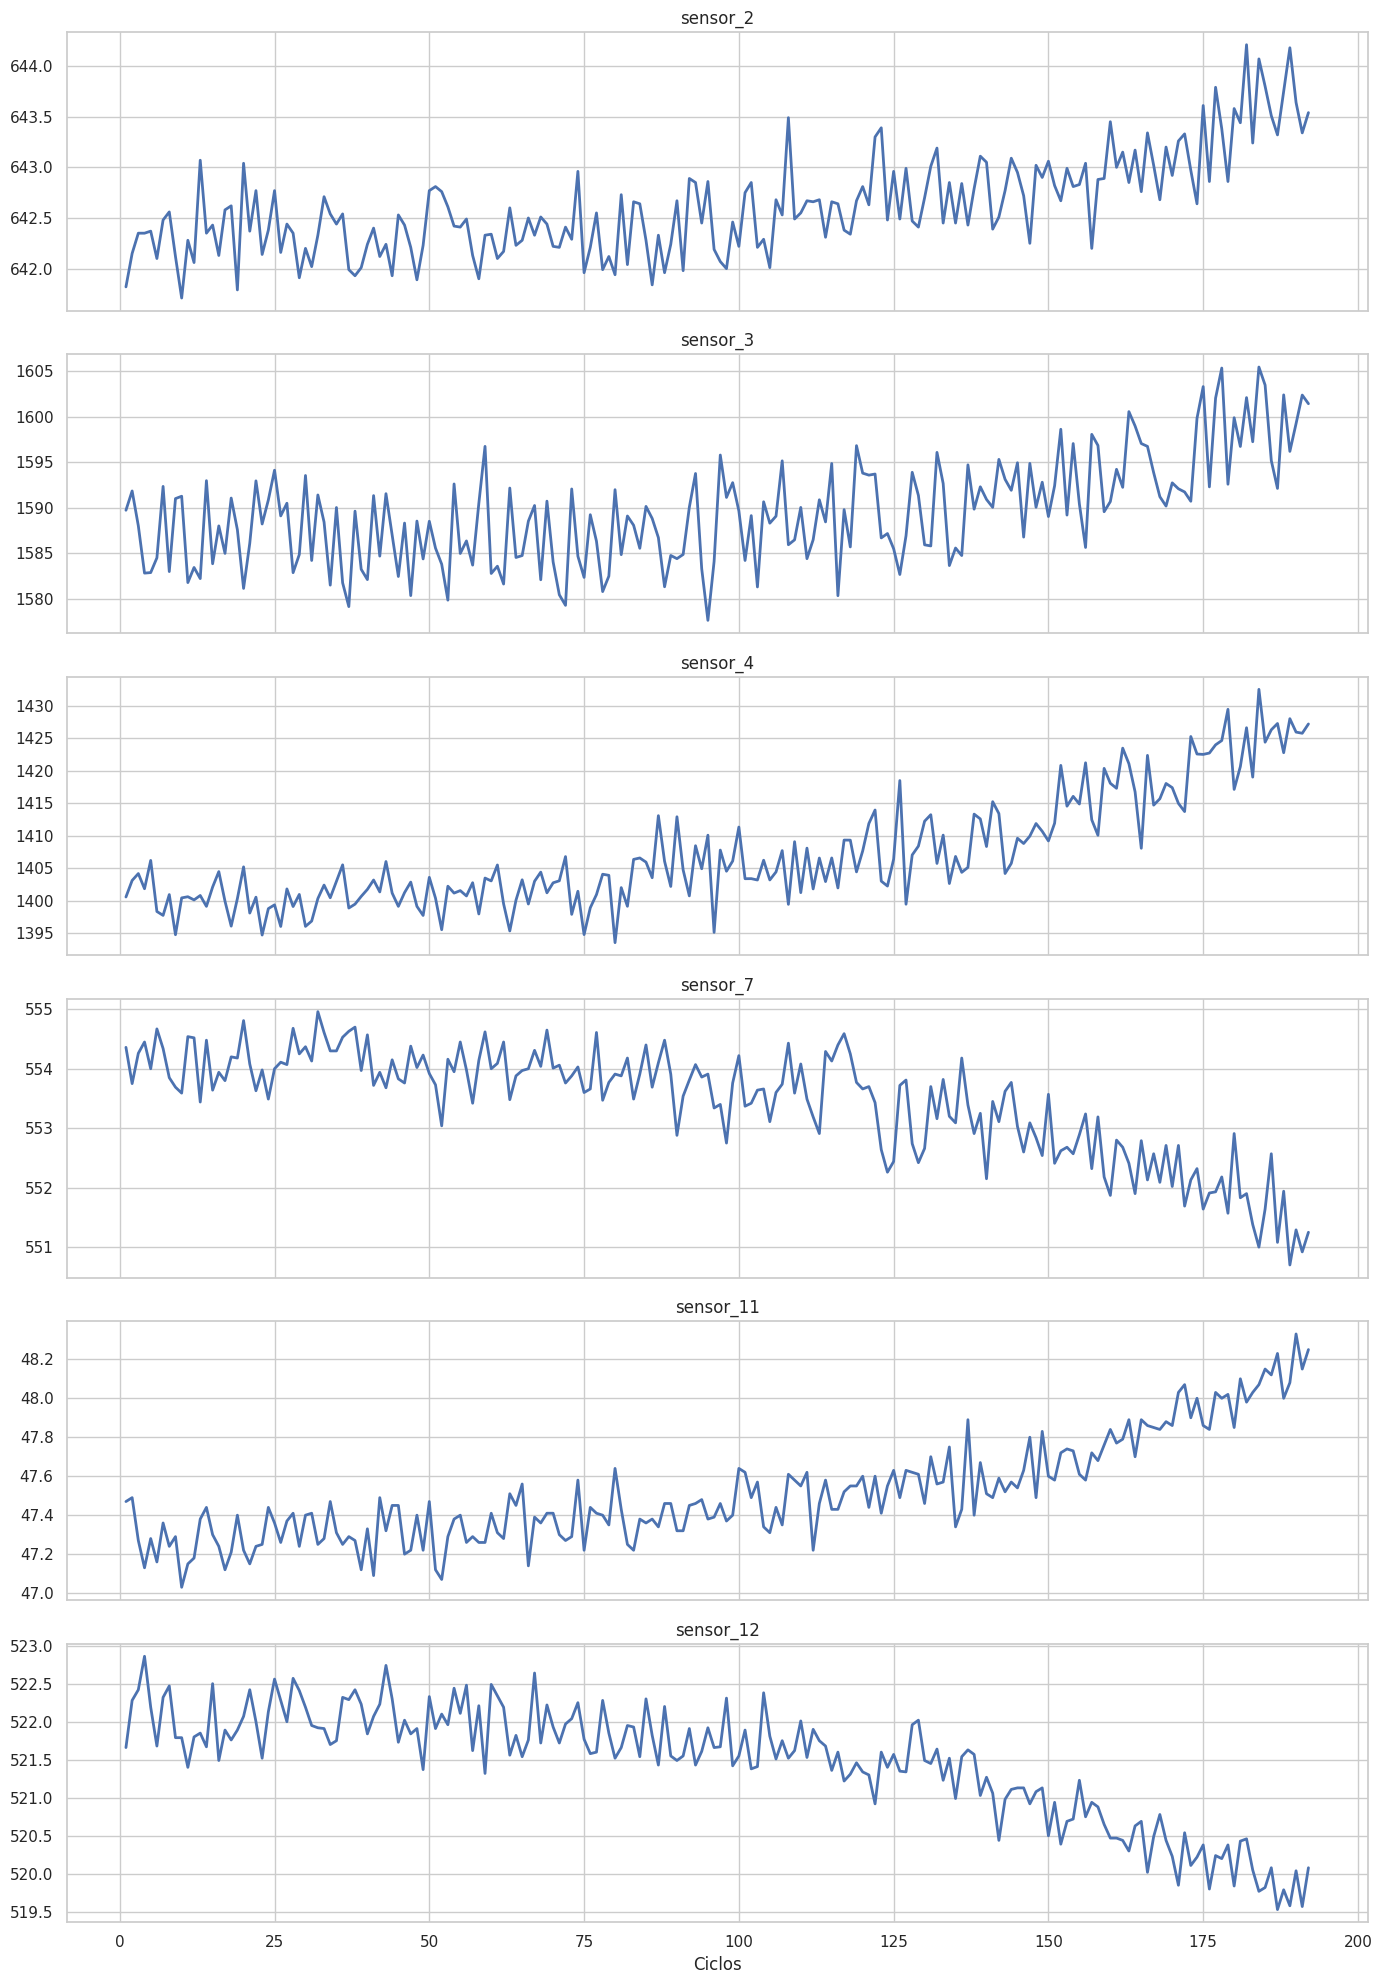

In [21]:
engine_id = 1

engine_df = train_df[
    train_df["unit_number"] == engine_id
]

fig, axes = plt.subplots(
    len(selected_sensors),
    1,
    figsize=(14, 20),
    sharex=True
)

for i, sensor in enumerate(selected_sensors):

    axes[i].plot(
        engine_df["time_in_cycles"],
        engine_df[sensor],
        linewidth=2
    )

    axes[i].set_title(sensor)

plt.xlabel("Ciclos")

plt.tight_layout()
plt.show()

# 3. Construção do Remaining Useful Life (RUL)

O Remaining Useful Life (RUL) representa quantos ciclos de operação ainda restam até a falha do equipamento.

Como os motores do conjunto de treino são observados até a falha, conseguimos calcular diretamente o RUL utilizando:

RUL = ciclo_final - ciclo_atual

Esse target será a principal variável utilizada pelos modelos de Machine Learning.

## Encontrando o ciclo final de cada motor

In [22]:
max_cycles = (
    train_df
    .groupby("unit_number")["time_in_cycles"]
    .max()
    .reset_index()
)

max_cycles.columns = [
    "unit_number",
    "max_cycle"
]

max_cycles.head()

,unit_number,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [23]:
train_df = train_df.merge(
    max_cycles,
    on="unit_number",
    how="left"
)

train_df.head()

,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192


In [24]:
train_df["RUL"] = (
    train_df["max_cycle"] -
    train_df["time_in_cycles"]
)

train_df.head()

,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [25]:
train_df[
    [
        "unit_number",
        "time_in_cycles",
        "max_cycle",
        "RUL"
    ]
].head(15)

,unit_number,time_in_cycles,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


## Curva de degradação

Agora vamos observar como o RUL decai ao longo dos ciclos operacionais.

Essa curva representa o processo de envelhecimento do equipamento ao longo da operação.

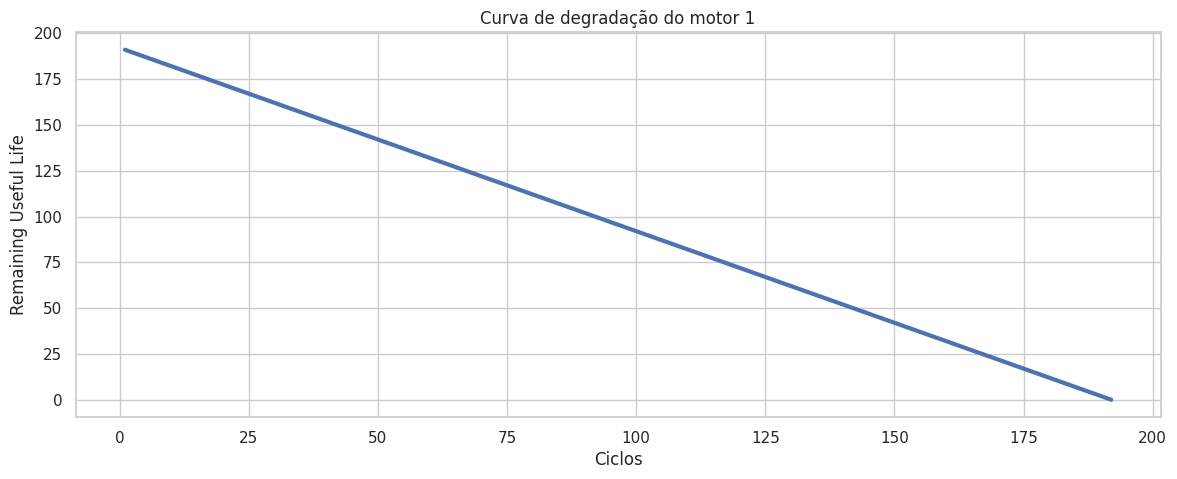

In [26]:
engine_id = 1

engine_df = train_df[
    train_df["unit_number"] == engine_id
]

plt.figure(figsize=(14, 5))

plt.plot(
    engine_df["time_in_cycles"],
    engine_df["RUL"],
    linewidth=3
)

plt.title(
    f"Curva de degradação do motor {engine_id}"
)

plt.xlabel("Ciclos")
plt.ylabel("Remaining Useful Life")

plt.show()

## Distribuição do RUL

A distribuição do RUL ajuda a entender:
- concentração de estados saudáveis;
- quantidade de amostras próximas da falha;
- desbalanceamento temporal do dataset.

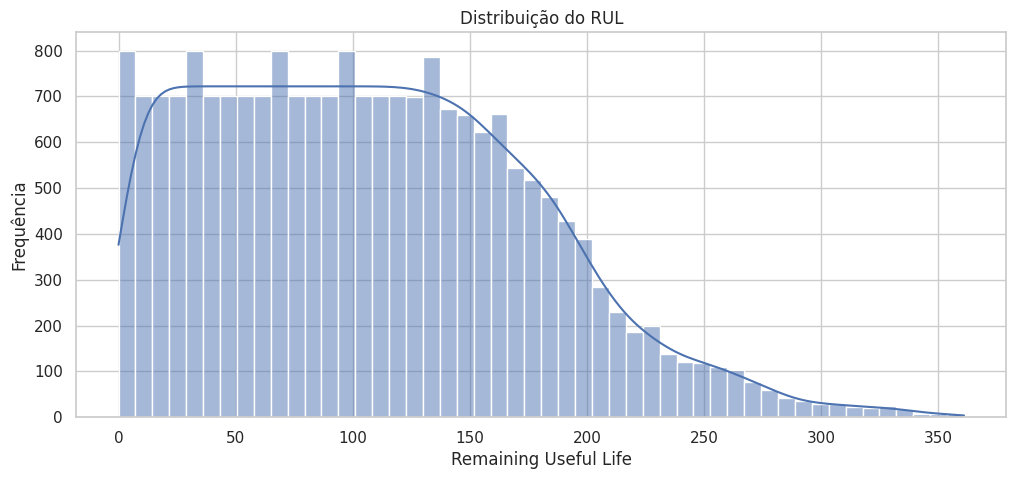

In [27]:
plt.figure(figsize=(12, 5))

sns.histplot(
    train_df["RUL"],
    bins=50,
    kde=True
)

plt.title("Distribuição do RUL")
plt.xlabel("Remaining Useful Life")
plt.ylabel("Frequência")

plt.show()

## Aplicando limite superior no RUL

Em muitos projetos industriais, valores muito altos de RUL possuem baixa relevância operacional.

Por isso, é comum aplicar um limite máximo no target, focando o modelo na região mais crítica da degradação.

In [28]:
RUL_CAP = 125

train_df["RUL_capped"] = (
    train_df["RUL"]
    .clip(upper=RUL_CAP)
)

train_df[
    [
        "RUL",
        "RUL_capped"
    ]
].head()

,RUL,RUL_capped
0,191,125
1,190,125
2,189,125
3,188,125
4,187,125


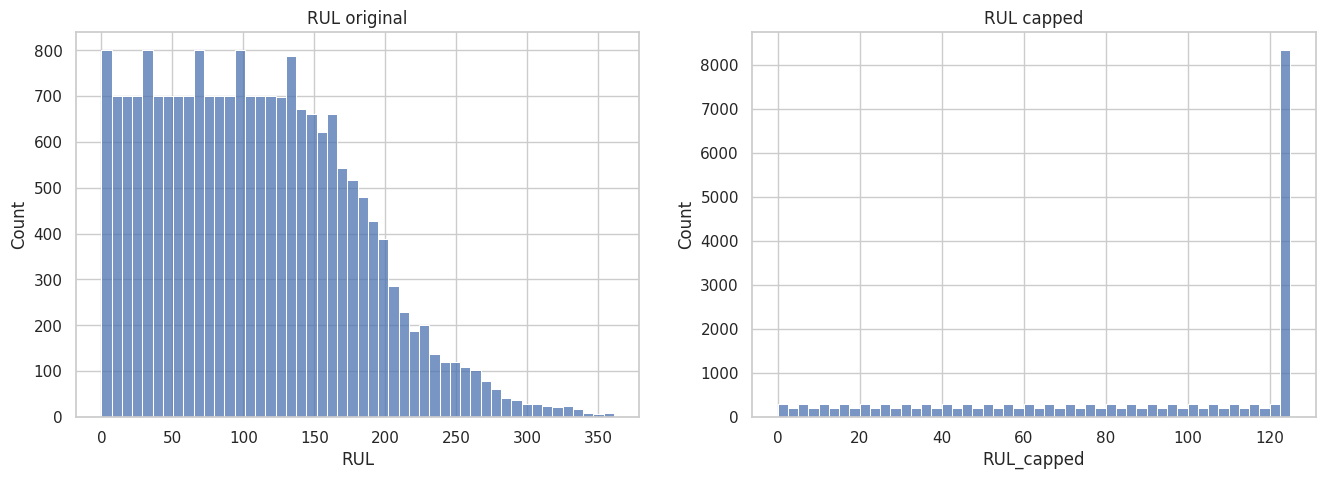

In [29]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

sns.histplot(
    train_df["RUL"],
    bins=50,
    ax=ax[0]
)

ax[0].set_title("RUL original")

sns.histplot(
    train_df["RUL_capped"],
    bins=50,
    ax=ax[1]
)

ax[1].set_title("RUL capped")

plt.show()

## Estados de saúde do equipamento

Além da regressão do RUL, também podemos interpretar o equipamento em diferentes estados operacionais.

Isso ajuda na criação de:
- alarmes;
- priorização;
- manutenção baseada em condição.

In [30]:
def health_state(rul):

    if rul > 80:
        return "Healthy"

    elif rul > 40:
        return "Degrading"

    else:
        return "Critical"

In [31]:
train_df["health_state"] = (
    train_df["RUL_capped"]
    .apply(health_state)
)

train_df[
    [
        "RUL_capped",
        "health_state"
    ]
].head()

,RUL_capped,health_state
0,125,Healthy
1,125,Healthy
2,125,Healthy
3,125,Healthy
4,125,Healthy


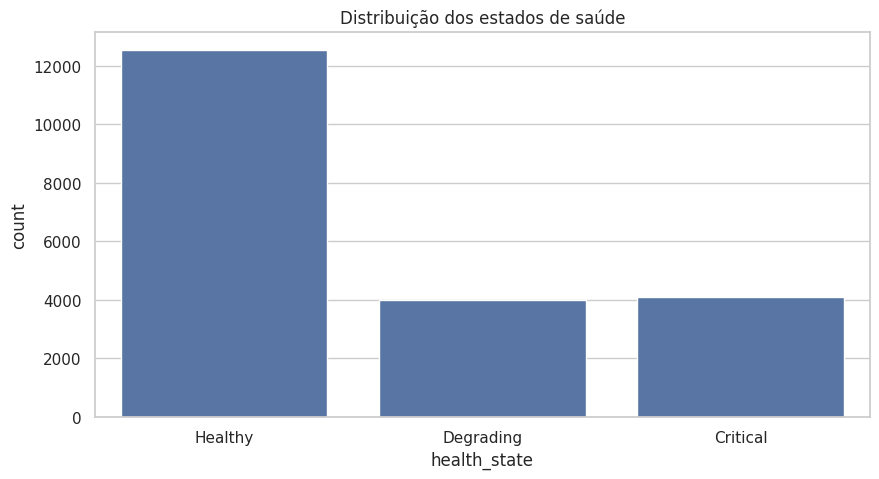

In [32]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train_df,
    x="health_state",
    order=[
        "Healthy",
        "Degrading",
        "Critical"
    ]
)

plt.title("Distribuição dos estados de saúde")

plt.show()

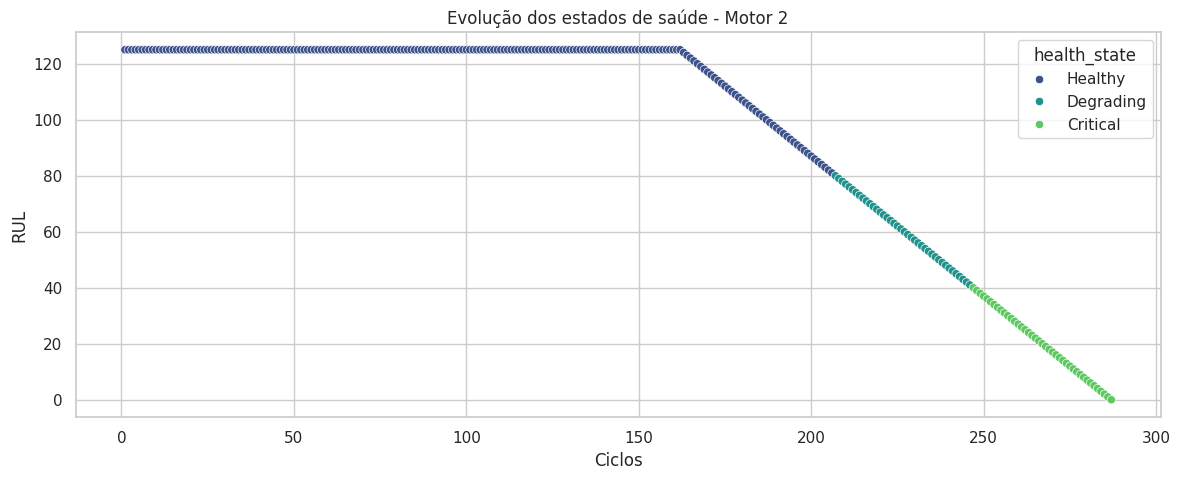

In [33]:
engine_id = 2

engine_df = train_df[
    train_df["unit_number"] == engine_id
]

plt.figure(figsize=(14, 5))

sns.scatterplot(
    data=engine_df,
    x="time_in_cycles",
    y="RUL_capped",
    hue="health_state",
    palette="viridis"
)

plt.title(
    f"Evolução dos estados de saúde - Motor {engine_id}"
)

plt.xlabel("Ciclos")
plt.ylabel("RUL")

plt.show()

# 4. Operational Guard Rails

Nesta seção vamos construir uma camada de **guard rails operacionais**.

A ideia é simular regras de negócio e limites de engenharia capazes de indicar quando um sensor apresenta uma medição fora do comportamento esperado.

Em um ambiente industrial real, esses limites poderiam vir de:

- manuais técnicos;
- recomendações do fabricante;
- histórico operacional;
- limites de segurança;
- experiência de especialistas de manutenção.

Como o dataset NASA CMAPSS não fornece limites oficiais de operação dos sensores, vamos criar limites estatísticos baseados no comportamento histórico dos motores.

### Seleção dos sensores relevantes

Vamos começar usando sensores que normalmente apresentam comportamento mais informativo no FD001.

In [34]:
guardrail_sensors = [
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_7",
    "sensor_11",
    "sensor_12",
    "sensor_15",
    "sensor_20",
    "sensor_21"
]

guardrail_sensors

['sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_7',
 'sensor_11',
 'sensor_12',
 'sensor_15',
 'sensor_20',
 'sensor_21']

### Criando limites estatísticos

Aqui vamos criar limites por percentis.

A lógica será:

* abaixo do percentil 5% → possível anomalia baixa;

* acima do percentil 95% → possível anomalia alta.

In [35]:
guardrail_limits = []

for sensor in guardrail_sensors:

    lower_limit = train_df[sensor].quantile(0.05)
    upper_limit = train_df[sensor].quantile(0.95)
    median_value = train_df[sensor].median()

    guardrail_limits.append(
        {
            "sensor": sensor,
            "lower_limit_p05": lower_limit,
            "median": median_value,
            "upper_limit_p95": upper_limit
        }
    )

guardrail_limits_df = pd.DataFrame(guardrail_limits)

guardrail_limits_df

,sensor,lower_limit_p05,median,upper_limit_p95
0,sensor_2,641.92000,642.6400,643.5800
1,sensor_3,1581.11000,1590.1000,1601.4700
2,sensor_4,1395.62000,1408.0400,1425.6700
3,sensor_7,551.74000,553.4400,554.6900
4,sensor_11,47.15000,47.5100,48.0450
5,sensor_12,520.04000,521.4800,522.5000
6,sensor_15,8.38590,8.4389,8.5110
7,sensor_20,38.49000,38.8300,39.0900
8,sensor_21,23.09345,23.2979,23.4535


#### Visualizando os limites

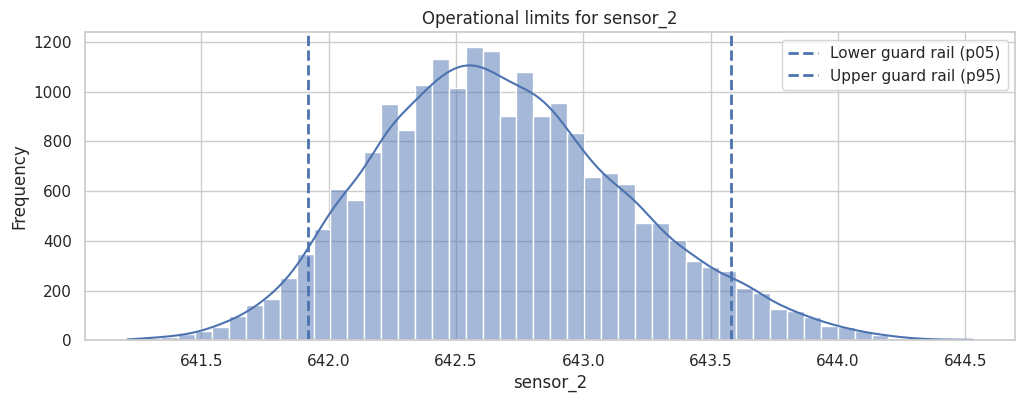

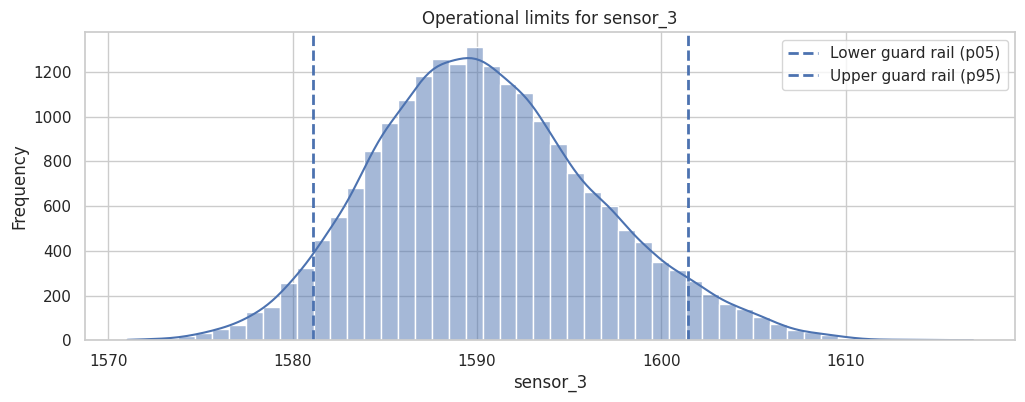

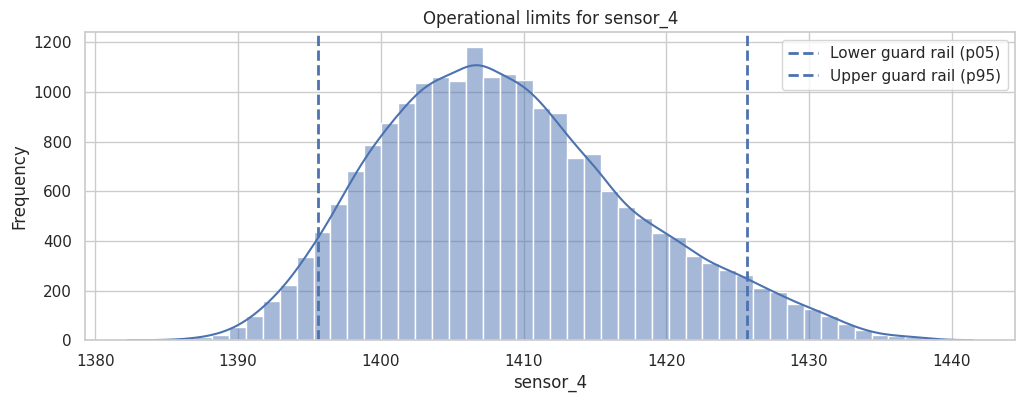

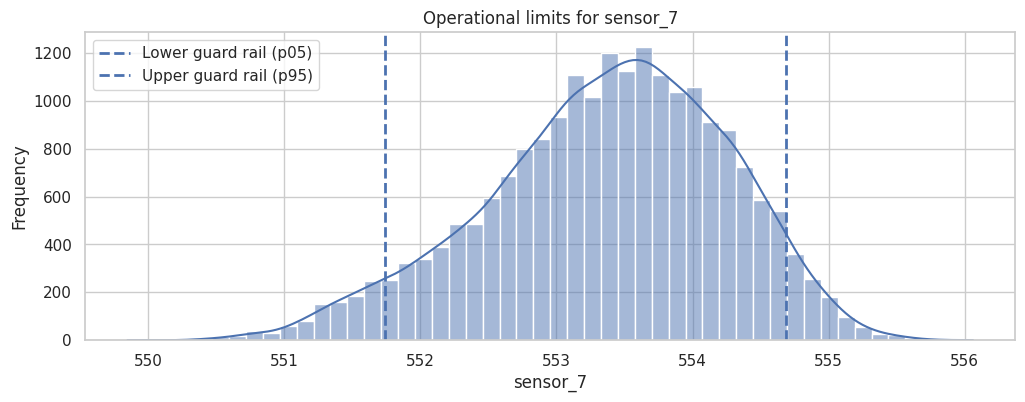

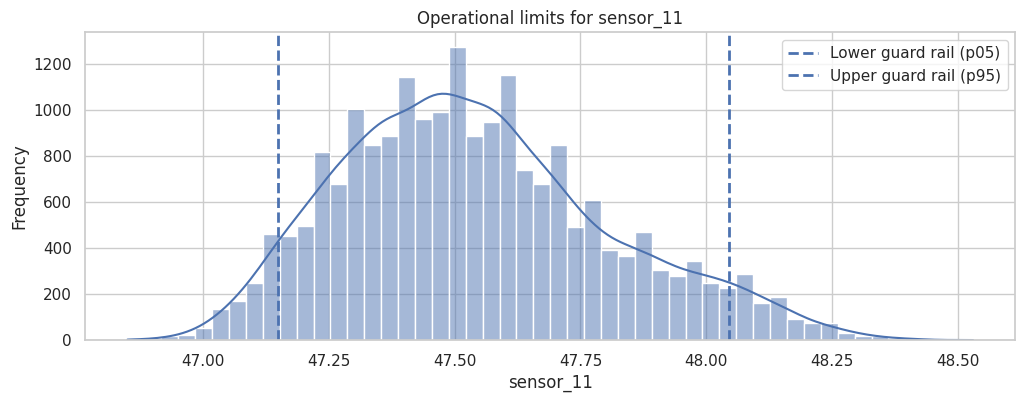

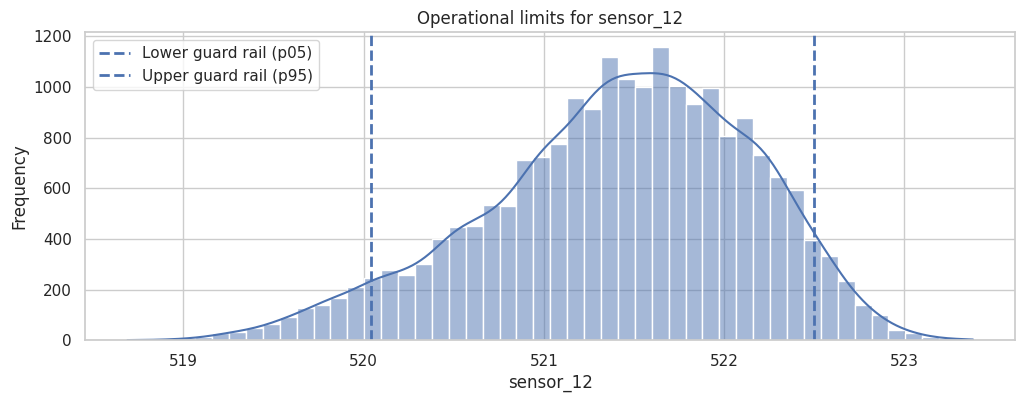

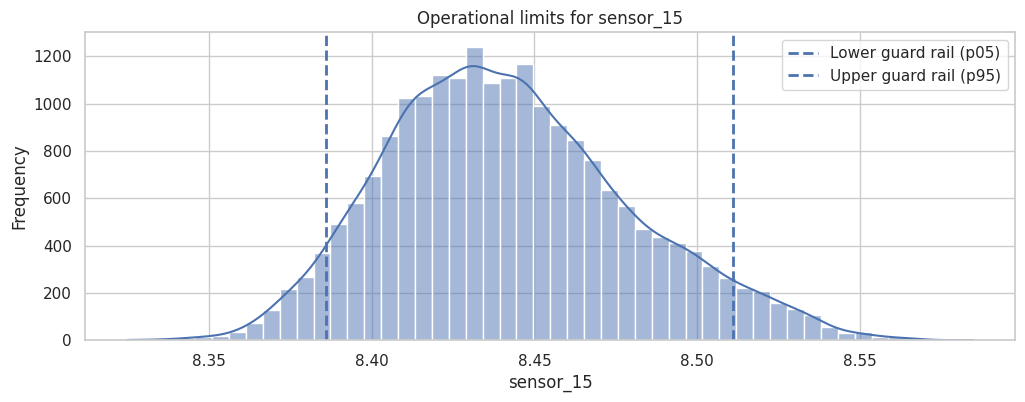

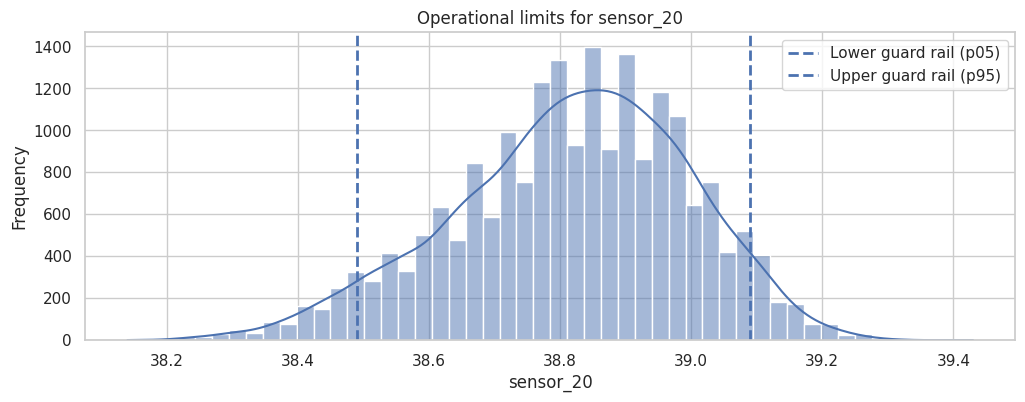

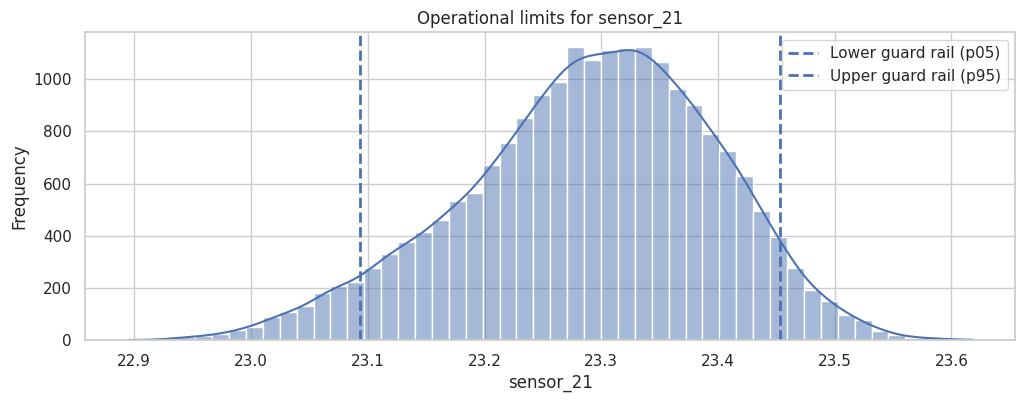

In [36]:
for sensor in guardrail_sensors:

    lower_limit = guardrail_limits_df.loc[
        guardrail_limits_df["sensor"] == sensor,
        "lower_limit_p05"
    ].values[0]

    upper_limit = guardrail_limits_df.loc[
        guardrail_limits_df["sensor"] == sensor,
        "upper_limit_p95"
    ].values[0]

    plt.figure(figsize=(12, 4))

    sns.histplot(
        train_df[sensor],
        bins=50,
        kde=True
    )

    plt.axvline(
        lower_limit,
        linestyle="--",
        linewidth=2,
        label="Lower guard rail (p05)"
    )

    plt.axvline(
        upper_limit,
        linestyle="--",
        linewidth=2,
        label="Upper guard rail (p95)"
    )

    plt.title(f"Operational limits for {sensor}")
    plt.xlabel(sensor)
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()

### Aplicando alertas por sensor

In [37]:
for sensor in guardrail_sensors:

    lower_limit = guardrail_limits_df.loc[
        guardrail_limits_df["sensor"] == sensor,
        "lower_limit_p05"
    ].values[0]

    upper_limit = guardrail_limits_df.loc[
        guardrail_limits_df["sensor"] == sensor,
        "upper_limit_p95"
    ].values[0]

    train_df[f"{sensor}_low_alert"] = (
        train_df[sensor] < lower_limit
    ).astype(int)

    train_df[f"{sensor}_high_alert"] = (
        train_df[sensor] > upper_limit
    ).astype(int)

### Total de alertas por leitura

In [38]:
alert_columns = [
    col for col in train_df.columns
    if col.endswith("_alert")
]

train_df["total_sensor_alerts"] = train_df[alert_columns].sum(axis=1)

train_df[
    [
        "unit_number",
        "time_in_cycles",
        "RUL_capped",
        "health_state",
        "total_sensor_alerts"
    ]
].head()

,unit_number,time_in_cycles,RUL_capped,health_state,total_sensor_alerts
0,1,1,125,Healthy,1
1,1,2,125,Healthy,0
2,1,3,125,Healthy,0
3,1,4,125,Healthy,3
4,1,5,125,Healthy,0


### Distribuição dos alertas

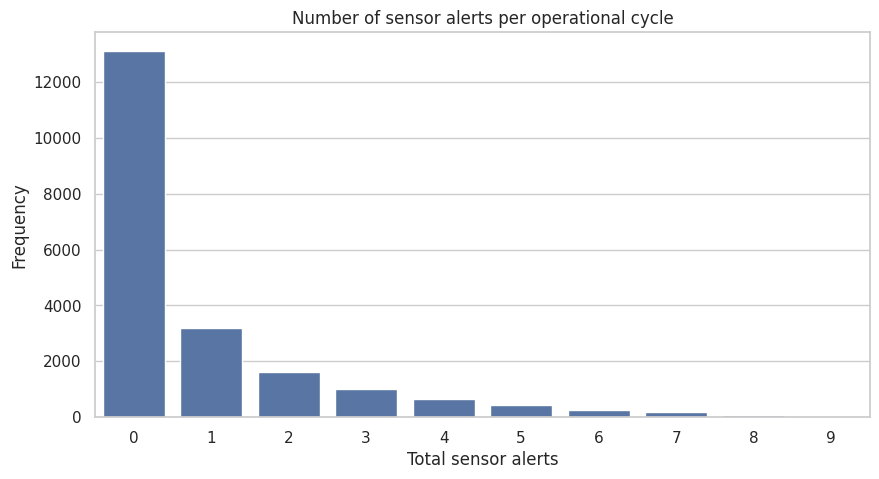

In [39]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train_df,
    x="total_sensor_alerts"
)

plt.title("Number of sensor alerts per operational cycle")
plt.xlabel("Total sensor alerts")
plt.ylabel("Frequency")

plt.show()

Alerta operacional agregado

In [40]:
def operational_status(total_alerts):

    if total_alerts == 0:
        return "Normal"

    elif total_alerts <= 2:
        return "Warning"

    else:
        return "Critical"

In [41]:
train_df["operational_status"] = (
    train_df["total_sensor_alerts"]
    .apply(operational_status)
)

train_df[
    [
        "unit_number",
        "time_in_cycles",
        "RUL_capped",
        "health_state",
        "total_sensor_alerts",
        "operational_status"
    ]
].head()

,unit_number,time_in_cycles,RUL_capped,health_state,total_sensor_alerts,operational_status
0,1,1,125,Healthy,1,Warning
1,1,2,125,Healthy,0,Normal
2,1,3,125,Healthy,0,Normal
3,1,4,125,Healthy,3,Critical
4,1,5,125,Healthy,0,Normal


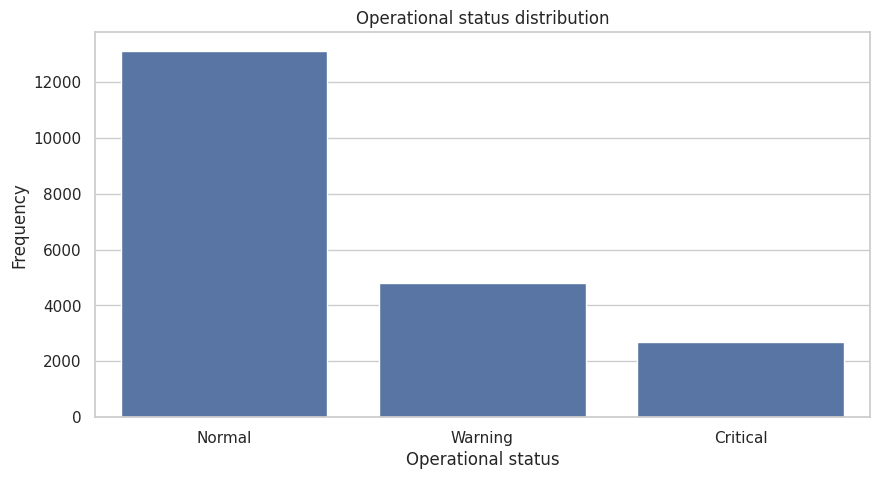

In [42]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train_df,
    x="operational_status",
    order=["Normal", "Warning", "Critical"]
)

plt.title("Operational status distribution")
plt.xlabel("Operational status")
plt.ylabel("Frequency")

plt.show()

#### Comparando guard rails com estado de saúde

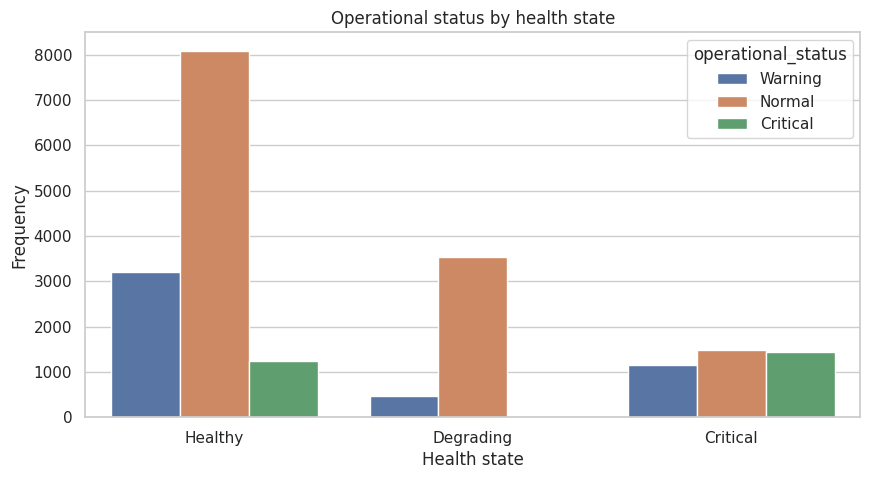

In [43]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train_df,
    x="health_state",
    hue="operational_status",
    order=["Healthy", "Degrading", "Critical"]
)

plt.title("Operational status by health state")
plt.xlabel("Health state")
plt.ylabel("Frequency")

plt.show()

### Evolução dos alertas em um motor

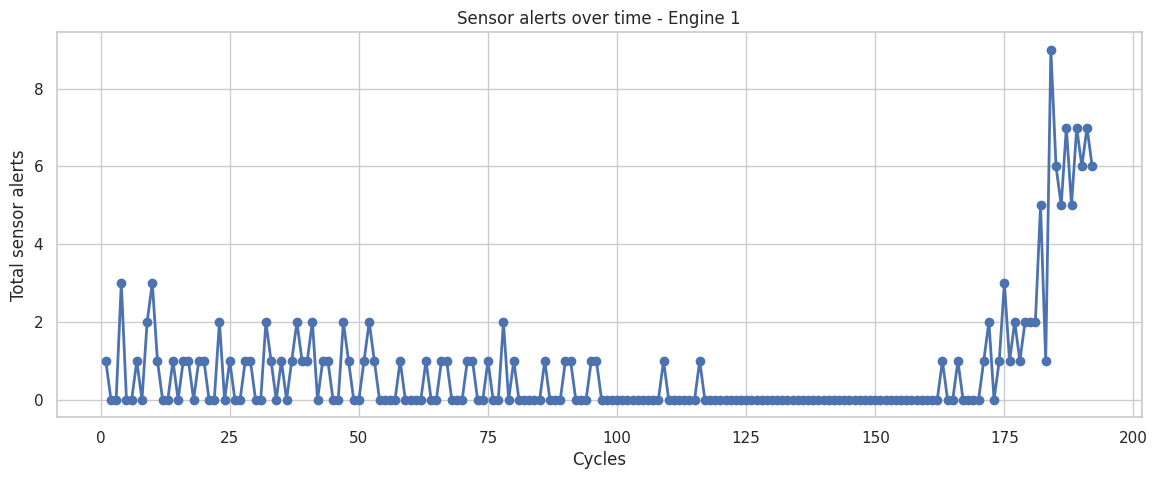

In [44]:
engine_id = 1

engine_df = train_df[
    train_df["unit_number"] == engine_id
]

plt.figure(figsize=(14, 5))

plt.plot(
    engine_df["time_in_cycles"],
    engine_df["total_sensor_alerts"],
    marker="o",
    linewidth=2
)

plt.title(f"Sensor alerts over time - Engine {engine_id}")
plt.xlabel("Cycles")
plt.ylabel("Total sensor alerts")

plt.show()

### Visualização conjunta: RUL e alertas

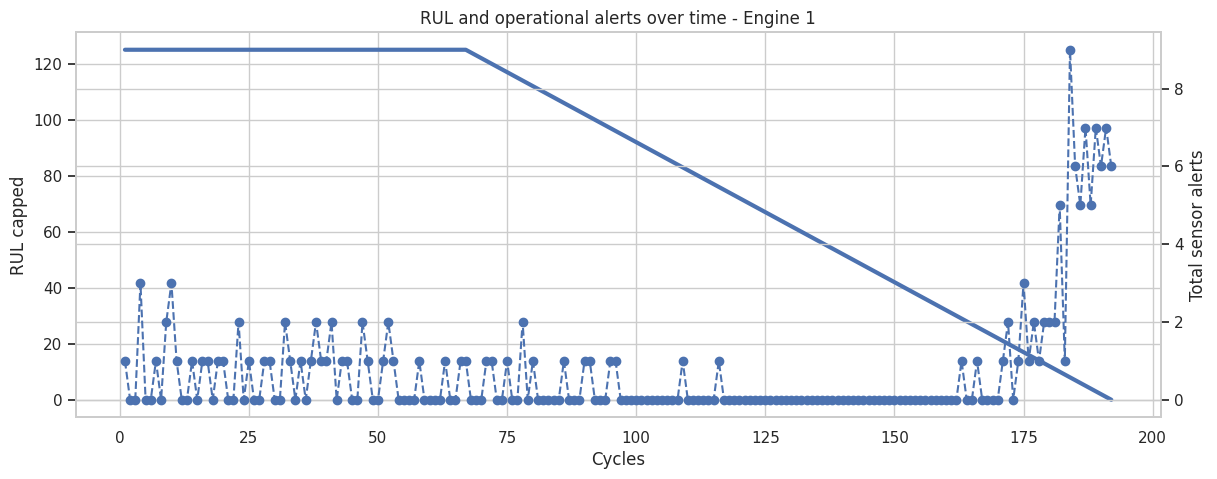

In [45]:
engine_id = 1

engine_df = train_df[
    train_df["unit_number"] == engine_id
]

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    engine_df["time_in_cycles"],
    engine_df["RUL_capped"],
    linewidth=3,
    label="RUL capped"
)

ax1.set_xlabel("Cycles")
ax1.set_ylabel("RUL capped")

ax2 = ax1.twinx()

ax2.plot(
    engine_df["time_in_cycles"],
    engine_df["total_sensor_alerts"],
    linestyle="--",
    marker="o",
    label="Sensor alerts"
)

ax2.set_ylabel("Total sensor alerts")

plt.title(f"RUL and operational alerts over time - Engine {engine_id}")

plt.show()

## Operational interpretation

The guard rails layer does not replace the Machine Learning model.

Instead, it provides an additional operational safety layer that can help answer questions such as:

- Is this sensor reading outside the expected historical range?
- Is the equipment showing multiple abnormal signals at the same time?
- Are alerts becoming more frequent as the equipment approaches failure?
- Should this asset be prioritized for inspection?

In real industrial systems, this type of rule-based layer is commonly combined with predictive models to improve trust, explainability and operational adoption.

# 5. Feature Engineering

Em sistemas industriais, o comportamento temporal dos sensores costuma ser mais importante do que medições isoladas.

Nesta etapa vamos criar variáveis capazes de representar:

- tendências de degradação;
- instabilidade operacional;
- mudanças abruptas;
- comportamento acumulado ao longo do tempo.

Essas features ajudam os modelos a entenderem melhor o processo de envelhecimento do equipamento.

In [46]:
feature_sensors = [
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_7",
    "sensor_11",
    "sensor_12",
    "sensor_15",
    "sensor_20",
    "sensor_21"
]

feature_sensors

['sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_7',
 'sensor_11',
 'sensor_12',
 'sensor_15',
 'sensor_20',
 'sensor_21']

In [47]:
train_df = train_df.sort_values(
    by=[
        "unit_number",
        "time_in_cycles"
    ]
)

## Rolling Mean

A média móvel ajuda a suavizar ruídos operacionais e capturar tendências de degradação ao longo do tempo.

In [48]:
ROLLING_WINDOW = 5

for sensor in feature_sensors:

    train_df[f"{sensor}_rolling_mean"] = (
        train_df
        .groupby("unit_number")[sensor]
        .transform(
            lambda x: x.rolling(
                window=ROLLING_WINDOW,
                min_periods=1
            ).mean()
        )
    )

## Rolling Standard Deviation

O desvio padrão móvel ajuda a identificar aumento de instabilidade operacional dos sensores.

In [49]:
for sensor in feature_sensors:

    train_df[f"{sensor}_rolling_std"] = (
        train_df
        .groupby("unit_number")[sensor]
        .transform(
            lambda x: x.rolling(
                window=ROLLING_WINDOW,
                min_periods=1
            ).std()
        )
    )

## Sensor Delta

A diferença entre leituras consecutivas pode indicar mudanças abruptas de comportamento operacional.

In [50]:
for sensor in feature_sensors:

    train_df[f"{sensor}_delta"] = (
        train_df
        .groupby("unit_number")[sensor]
        .diff()
    )

## Exponential Moving Average (EMA)

A média móvel exponencial atribui maior peso às observações mais recentes, ajudando a capturar degradações recentes do equipamento.

In [51]:
for sensor in feature_sensors:

    train_df[f"{sensor}_ema"] = (
        train_df
        .groupby("unit_number")[sensor]
        .transform(
            lambda x: x.ewm(span=10).mean()
        )
    )

## Sensor Trend

A inclinação temporal dos sensores ajuda a identificar a velocidade de degradação operacional.

In [52]:
for sensor in feature_sensors:

    train_df[f"{sensor}_trend"] = (
        train_df
        .groupby("unit_number")[sensor]
        .diff(periods=3)
    )

## Health Indicator

Vamos criar um indicador simples de saúde operacional baseado na quantidade de alertas ativos.

In [53]:
train_df["health_indicator"] = (
    1 /
    (
        1 +
        train_df["total_sensor_alerts"]
    )
)

train_df[
    [
        "total_sensor_alerts",
        "health_indicator"
    ]
].head()

,total_sensor_alerts,health_indicator
0,1,0.50
1,0,1.00
2,0,1.00
3,3,0.25
4,0,1.00


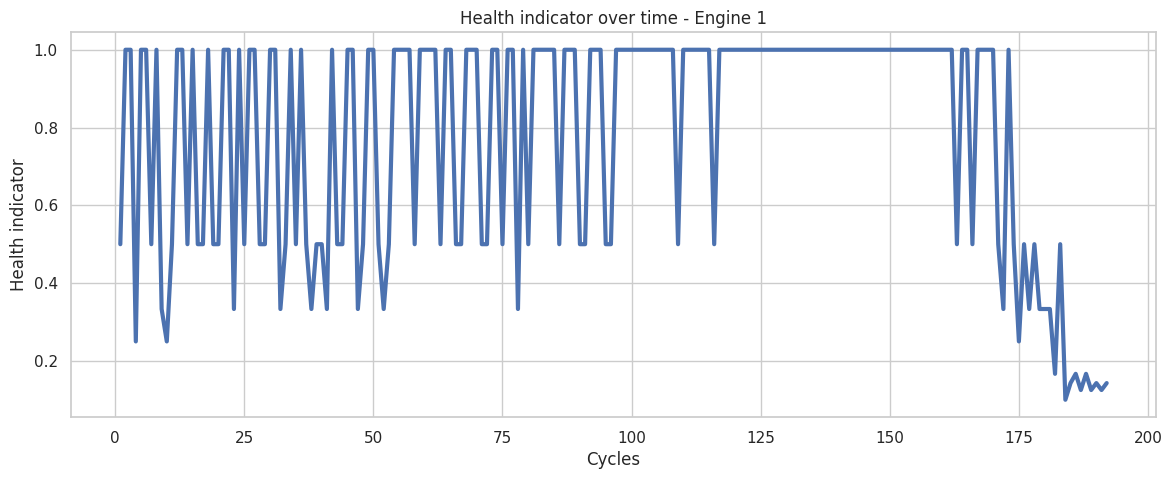

In [54]:
engine_id = 1

engine_df = train_df[
    train_df["unit_number"] == engine_id
]

plt.figure(figsize=(14, 5))

plt.plot(
    engine_df["time_in_cycles"],
    engine_df["health_indicator"],
    linewidth=3
)

plt.title(
    f"Health indicator over time - Engine {engine_id}"
)

plt.xlabel("Cycles")
plt.ylabel("Health indicator")

plt.show()

In [55]:
train_df = train_df.dropna().reset_index(drop=True)

train_df.shape

(20331, 96)

In [56]:
engineered_features = [
    col for col in train_df.columns
    if (
        "rolling" in col
        or "delta" in col
        or "ema" in col
        or "trend" in col
    )
]

len(engineered_features)

45

In [57]:
engineered_features[:20]

['sensor_2_rolling_mean',
 'sensor_3_rolling_mean',
 'sensor_4_rolling_mean',
 'sensor_7_rolling_mean',
 'sensor_11_rolling_mean',
 'sensor_12_rolling_mean',
 'sensor_15_rolling_mean',
 'sensor_20_rolling_mean',
 'sensor_21_rolling_mean',
 'sensor_2_rolling_std',
 'sensor_3_rolling_std',
 'sensor_4_rolling_std',
 'sensor_7_rolling_std',
 'sensor_11_rolling_std',
 'sensor_12_rolling_std',
 'sensor_15_rolling_std',
 'sensor_20_rolling_std',
 'sensor_21_rolling_std',
 'sensor_2_delta',
 'sensor_3_delta']

## Relação das features com o RUL

Agora vamos identificar quais variáveis possuem maior relação com a degradação do equipamento.

In [58]:
feature_correlation = (
    train_df[
        engineered_features + ["RUL_capped"]
    ]
    .corr()["RUL_capped"]
    .sort_values()
)

feature_correlation.head(20)

,RUL_capped
sensor_4_rolling_mean,-0.816907
sensor_4_ema,-0.816255
sensor_15_ema,-0.816145
sensor_11_rolling_mean,-0.815200
sensor_3_ema,-0.813822
sensor_15_rolling_mean,-0.811790
sensor_11_ema,-0.810800
sensor_2_ema,-0.806416
sensor_3_rolling_mean,-0.797143
sensor_2_rolling_mean,-0.796570


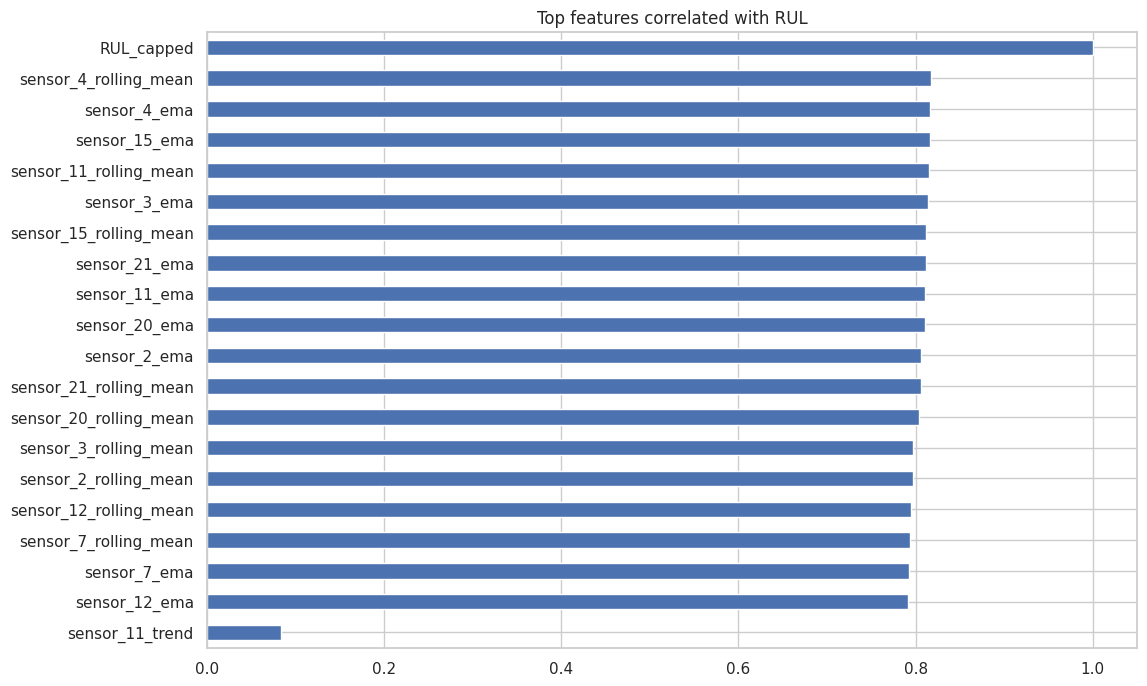

In [59]:
top_features = (
    feature_correlation
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12, 8))

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top features correlated with RUL")

plt.show()


In [60]:
model_features = (
    feature_sensors +
    engineered_features +
    [
        "total_sensor_alerts",
        "health_indicator"
    ]
)

X = train_df[model_features]

y = train_df["RUL_capped"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (20331, 56)
Shape y: (20331,)


# 6. RUL Modeling

Agora vamos iniciar a modelagem do Remaining Useful Life (RUL).

Começaremos com um modelo baseline simples para criar uma referência inicial de desempenho.

Em seguida, poderemos evoluir para modelos mais robustos como:
- Random Forest;
- XGBoost;
- modelos temporais avançados.

O objetivo do baseline não é atingir a melhor performance possível, mas sim estabelecer um ponto de comparação confiável.

## Train/Validation Split

Como os dados possuem dependência temporal por motor, o split será realizado por unidade operacional (`unit_number`) e não aleatoriamente por linha.

Isso evita vazamento temporal e torna a avaliação mais realista.

In [61]:
from sklearn.model_selection import GroupShuffleSplit

In [62]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RANDOM_STATE
)

groups = train_df["unit_number"]

train_idx, val_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (16321, 56)
Validation shape: (4010, 56)


## Baseline Model — Linear Regression

A regressão linear será utilizada como baseline inicial.

Apesar de simples, ela fornece uma boa referência para avaliar o ganho obtido com modelos mais complexos.

In [63]:
baseline_model = LinearRegression()

baseline_model.fit(
    X_train,
    y_train
)

LinearRegression()

In [64]:
baseline_predictions = baseline_model.predict(X_val)

## Baseline Evaluation

Vamos avaliar o modelo utilizando:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

Essas métricas ajudam a entender o erro médio e a capacidade do modelo em explicar a degradação do equipamento.

In [65]:
baseline_mae = mean_absolute_error(
    y_val,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_val,
    baseline_predictions
)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R²: {baseline_r2:.4f}")

Baseline MAE: 16.04
Baseline RMSE: 20.02
Baseline R²: 0.7702


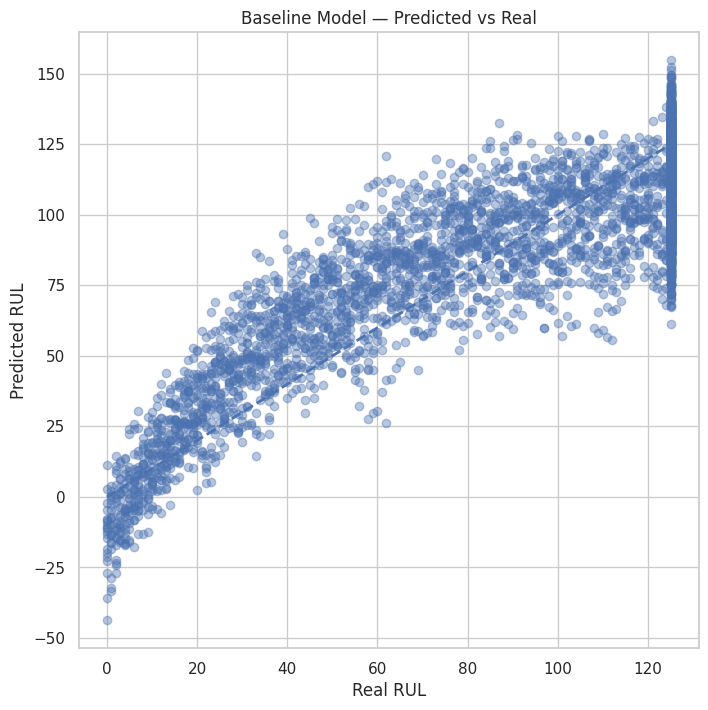

In [66]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_val,
    baseline_predictions,
    alpha=0.4
)

plt.plot(
    [0, RUL_CAP],
    [0, RUL_CAP],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Real RUL")
plt.ylabel("Predicted RUL")

plt.title("Baseline Model — Predicted vs Real")

plt.show()

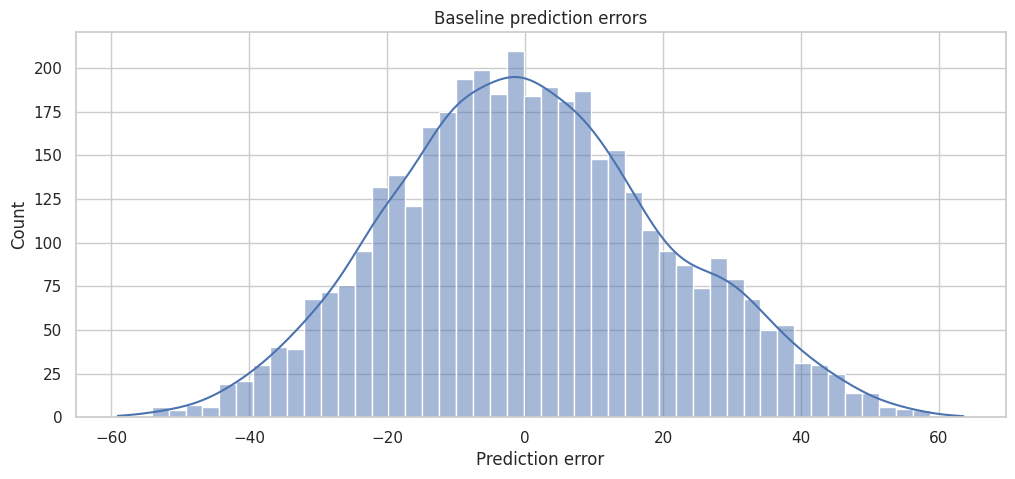

In [67]:
baseline_errors = (
    y_val -
    baseline_predictions
)

plt.figure(figsize=(12, 5))

sns.histplot(
    baseline_errors,
    bins=50,
    kde=True
)

plt.title("Baseline prediction errors")
plt.xlabel("Prediction error")

plt.show()

## Operational Evaluation

Em manutenção preditiva, erros próximos da falha costumam ser mais críticos do que erros em regiões saudáveis.

Por isso, também vamos avaliar o modelo apenas em estados críticos do equipamento.

In [68]:
critical_mask = y_val <= 40

critical_mae = mean_absolute_error(
    y_val[critical_mask],
    baseline_predictions[critical_mask]
)

print(f"Critical Region MAE: {critical_mae:.2f}")

Critical Region MAE: 14.15


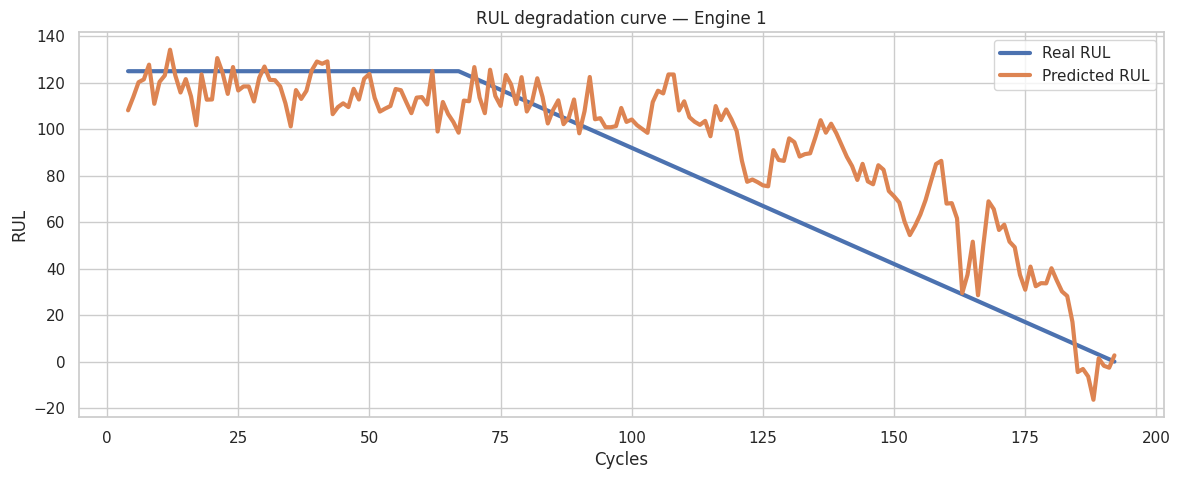

In [69]:
validation_engine = (
    train_df.iloc[val_idx]["unit_number"]
    .unique()[0]
)

engine_validation_df = train_df.iloc[val_idx]

engine_validation_df = engine_validation_df[
    engine_validation_df["unit_number"] == validation_engine
]

engine_X = engine_validation_df[model_features]

engine_predictions = baseline_model.predict(engine_X)

plt.figure(figsize=(14, 5))

plt.plot(
    engine_validation_df["time_in_cycles"],
    engine_validation_df["RUL_capped"],
    label="Real RUL",
    linewidth=3
)

plt.plot(
    engine_validation_df["time_in_cycles"],
    engine_predictions,
    label="Predicted RUL",
    linewidth=3
)

plt.xlabel("Cycles")
plt.ylabel("RUL")

plt.title(
    f"RUL degradation curve — Engine {validation_engine}"
)

plt.legend()

plt.show()

## Interpretação do Baseline

O modelo baseline baseado em Regressão Linear já consegue capturar parte importante da dinâmica de degradação dos motores.

Observando os gráficos, é possível perceber que:

- existe uma tendência clara entre o RUL real e o previsto;
- o modelo consegue acompanhar parcialmente a degradação temporal;
- os sensores e features temporais possuem capacidade preditiva relevante.

Entretanto, algumas limitações importantes aparecem:

### 1. Saturação em RULs elevados

O modelo apresenta dificuldade em diferenciar estados muito saudáveis do equipamento, concentrando diversas previsões próximas ao valor máximo do RUL.

Isso acontece porque a regressão linear possui baixa capacidade de representar relações não lineares complexas entre os sensores e o processo de degradação.

---

### 2. Oscilações na região crítica

Próximo da falha, o modelo apresenta maior instabilidade e erros mais elevados.

Em ambientes industriais reais, essa região costuma ser a mais importante operacionalmente, já que decisões de manutenção são tomadas justamente quando o equipamento se aproxima da falha.

---

### 3. Resíduos relativamente distribuídos

A distribuição dos erros mostra comportamento aproximadamente centrado em zero, indicando que o modelo não apresenta um viés extremo de superestimação ou subestimação.

Ainda assim, a dispersão dos resíduos mostra que existem padrões operacionais não capturados adequadamente pela modelagem linear.

---

### 4. Necessidade de modelos não lineares

Os resultados indicam que modelos capazes de capturar:
- interações complexas;
- comportamento temporal;
- degradação não linear;
- mudanças abruptas nos sensores;

devem apresentar desempenho significativamente superior.

Por isso, na próxima etapa iremos avaliar modelos baseados em árvores, começando com Random Forest e posteriormente XGBoost.

# 7. XGBoost Regressor

Agora vamos utilizar o XGBoost para modelar o RUL.

O XGBoost é um dos algoritmos mais utilizados em problemas tabulares industriais devido à sua capacidade de capturar:

- relações não lineares;
- interações complexas entre sensores;
- padrões de degradação;
- mudanças abruptas de comportamento operacional.

Além disso, o modelo possui excelente desempenho em problemas de manutenção preditiva e Remaining Useful Life (RUL).

In [70]:
from xgboost import XGBRegressor

In [71]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    objective="reg:squarederror"
)

In [72]:
xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [73]:
xgb_predictions = xgb_model.predict(X_val)

## Avaliação do XGBoost

Agora vamos comparar o desempenho do XGBoost com o baseline linear.

In [74]:
xgb_mae = mean_absolute_error(
    y_val,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_val,
    xgb_predictions
)

print(f"XGBoost MAE: {xgb_mae:.2f}")
print(f"XGBoost RMSE: {xgb_rmse:.2f}")
print(f"XGBoost R²: {xgb_r2:.4f}")

XGBoost MAE: 14.10
XGBoost RMSE: 19.05
XGBoost R²: 0.7919


In [75]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        xgb_rmse
    ],
    "R2": [
        baseline_r2,
        xgb_r2
    ]
})

comparison_df

,Model,MAE,RMSE,R2
0,Linear Regression,16.043577,20.016670,0.770193
1,XGBoost,14.100361,19.049584,0.791862


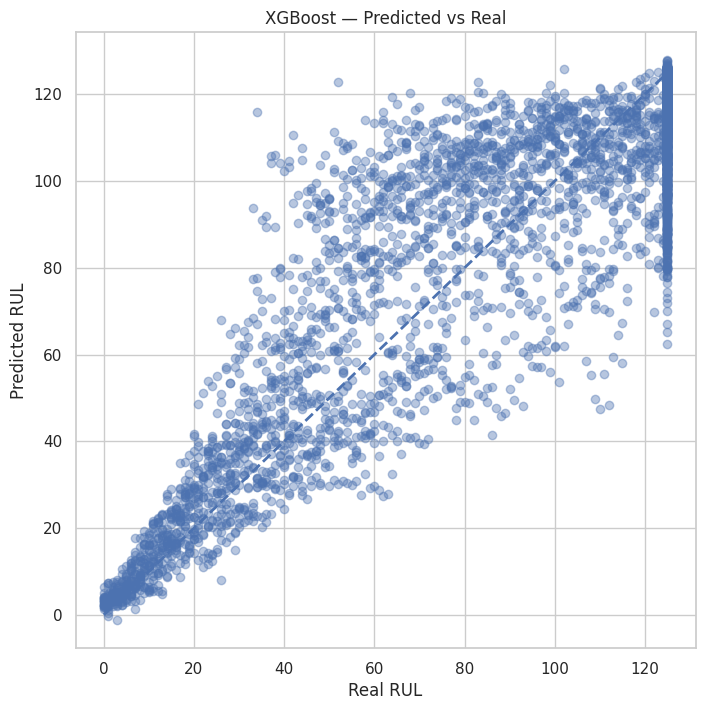

In [77]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_val,
    xgb_predictions,
    alpha=0.4
)

plt.plot(
    [0, RUL_CAP],
    [0, RUL_CAP],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Real RUL")
plt.ylabel("Predicted RUL")

plt.title("XGBoost — Predicted vs Real")

plt.show()

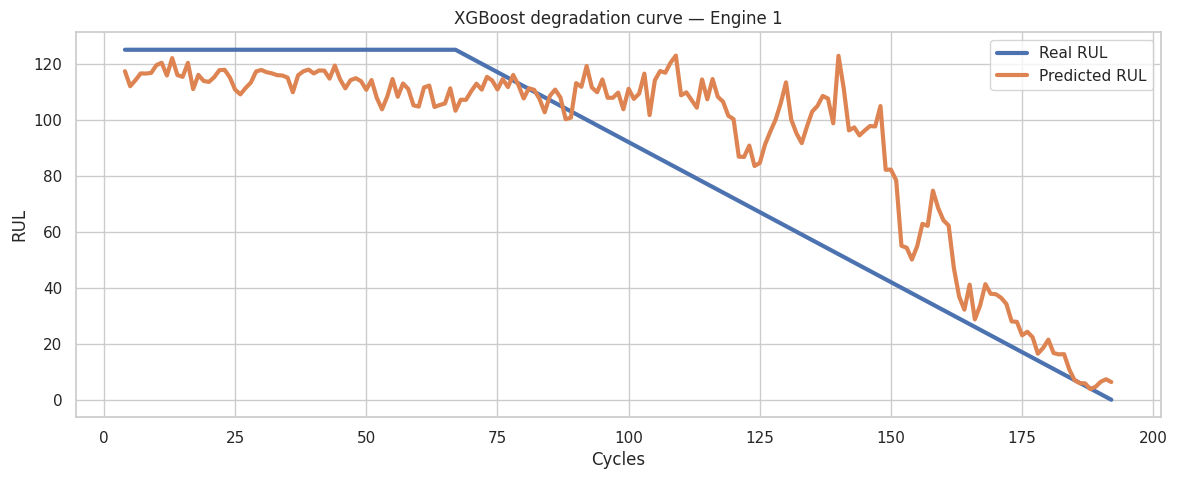

In [78]:
validation_engine = (
    train_df.iloc[val_idx]["unit_number"]
    .unique()[0]
)

engine_validation_df = train_df.iloc[val_idx]

engine_validation_df = engine_validation_df[
    engine_validation_df["unit_number"] == validation_engine
]

engine_X = engine_validation_df[model_features]

engine_predictions_xgb = xgb_model.predict(engine_X)

plt.figure(figsize=(14, 5))

plt.plot(
    engine_validation_df["time_in_cycles"],
    engine_validation_df["RUL_capped"],
    label="Real RUL",
    linewidth=3
)

plt.plot(
    engine_validation_df["time_in_cycles"],
    engine_predictions_xgb,
    label="Predicted RUL",
    linewidth=3
)

plt.xlabel("Cycles")
plt.ylabel("RUL")

plt.title(
    f"XGBoost degradation curve — Engine {validation_engine}"
)

plt.legend()

plt.show()

## Feature Importance

Uma vantagem importante do XGBoost é a capacidade de identificar quais sensores e features possuem maior impacto na previsão do RUL.

In [79]:
feature_importance = pd.DataFrame({
    "feature": model_features,
    "importance": xgb_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="importance",
        ascending=False
    )
)

feature_importance.head(15)

,feature,importance
38,sensor_4_ema,0.332190
11,sensor_4_rolling_mean,0.202908
37,sensor_3_ema,0.063087
36,sensor_2_ema,0.062412
42,sensor_15_ema,0.030246
13,sensor_11_rolling_mean,0.029183
44,sensor_21_ema,0.028589
15,sensor_15_rolling_mean,0.022507
16,sensor_20_rolling_mean,0.017904
17,sensor_21_rolling_mean,0.017332


In [80]:
critical_mask = y_val <= 40

xgb_critical_mae = mean_absolute_error(
    y_val[critical_mask],
    xgb_predictions[critical_mask]
)

print(
    f"XGBoost Critical Region MAE: "
    f"{xgb_critical_mae:.2f}"
)

XGBoost Critical Region MAE: 8.36


In [81]:
# comparison_df.set_index("Model")[
#     ["MAE", "RMSE"]
# ].plot(
#     kind="bar",
#     figsize=(10, 5)
# )

# plt.title("Model comparison")
# plt.ylabel("Error")

# plt.show()

## Interpretação do XGBoost

O XGBoost apresentou melhora consistente em relação ao baseline linear:

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 16.04 | 20.02 | 0.770 |
| XGBoost | 14.10 | 19.05 | 0.792 |

Os resultados indicam que o modelo conseguiu capturar padrões mais complexos de degradação presentes nos sensores e nas features temporais construídas anteriormente.

---

### 1. Melhor representação da degradação não linear

A curva temporal prevista pelo XGBoost apresenta comportamento significativamente mais próximo da degradação real do equipamento.

Diferente da regressão linear, o modelo consegue representar:
- mudanças abruptas;
- aceleração da degradação;
- regiões de comportamento não linear;
- interações entre sensores.

Isso é especialmente importante em manutenção preditiva, onde a degradação raramente ocorre de forma puramente linear.

---

### 2. Melhor desempenho na região crítica

O modelo apresenta melhor aderência nas regiões próximas da falha, reduzindo oscilações extremas observadas anteriormente no baseline.

Esse comportamento é operacionalmente relevante porque:
- erros próximos da falha possuem maior impacto;
- decisões de manutenção são tomadas justamente nessa região;
- previsões mais estáveis aumentam a confiabilidade operacional do sistema.

---

### 3. Saturação parcial em RULs elevados

Apesar da melhora geral, ainda existe certa concentração de previsões próximas ao limite superior do RUL.

Isso sugere que:
- estados muito saudáveis possuem comportamento semelhante entre si;
- alguns sensores possuem baixa capacidade discriminativa em regiões iniciais da vida útil;
- o modelo ainda possui dificuldade para separar motores muito saudáveis.

Esse comportamento é relativamente comum em problemas de Remaining Useful Life.

---

### 4. Maior capacidade de modelar interações entre sensores

A dispersão entre valores reais e previstos mostra que o modelo passou a capturar relações mais complexas entre:
- tendências temporais;
- rolling statistics;
- instabilidade operacional;
- guard rails;
- degradação acumulada.

Isso evidencia o ganho obtido pelo uso de:
- feature engineering temporal;
- indicadores operacionais;
- modelos baseados em Gradient Boosting.

---

# 8. LightGBM Regressor

Agora vamos avaliar o LightGBM, outro algoritmo amplamente utilizado em problemas industriais tabulares.

O LightGBM possui:
- treinamento extremamente rápido;
- excelente desempenho;
- boa escalabilidade;
- forte capacidade de generalização.

In [82]:
from lightgbm import LGBMRegressor

In [83]:
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE
)

In [84]:
lgbm_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018466 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13202
[LightGBM] [Info] Number of data points in the train set: 16321, number of used features: 56
[LightGBM] [Info] Start training from score 86.399424
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
              n_estimators=300, random_state=42, subsample=0.8)

In [85]:
lgbm_predictions = lgbm_model.predict(X_val)

In [86]:
lgbm_mae = mean_absolute_error(
    y_val,
    lgbm_predictions
)

lgbm_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        lgbm_predictions
    )
)

lgbm_r2 = r2_score(
    y_val,
    lgbm_predictions
)

print(f"LightGBM MAE: {lgbm_mae:.2f}")
print(f"LightGBM RMSE: {lgbm_rmse:.2f}")
print(f"LightGBM R²: {lgbm_r2:.4f}")

LightGBM MAE: 14.01
LightGBM RMSE: 18.99
LightGBM R²: 0.7932


In [87]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost",
        "LightGBM"
    ],
    "MAE": [
        baseline_mae,
        xgb_mae,
        lgbm_mae
    ],
    "RMSE": [
        baseline_rmse,
        xgb_rmse,
        lgbm_rmse
    ],
    "R2": [
        baseline_r2,
        xgb_r2,
        lgbm_r2
    ]
})

comparison_df

,Model,MAE,RMSE,R2
0,Linear Regression,16.043577,20.016670,0.770193
1,XGBoost,14.100361,19.049584,0.791862
2,LightGBM,14.014905,18.986612,0.793236


# 9. Comparação Final dos Modelos

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 16.04 | 20.02 | 0.770 |
| XGBoost | 14.10 | 19.05 | 0.792 |
| LightGBM | 14.01 | 18.99 | 0.793 |

Os resultados mostram uma melhoria consistente dos modelos baseados em Gradient Boosting em relação ao baseline linear.

---

## 1. Baseline Linear Regression

A regressão linear conseguiu capturar parte importante da degradação dos motores, demonstrando que os sensores e features temporais possuem relação significativa com o RUL.

Entretanto, o modelo apresentou limitações importantes:
- dificuldade em representar relações não lineares;
- saturação em regiões de RUL elevado;
- maior instabilidade próximo da falha;
- baixa capacidade de capturar interações complexas entre sensores.

Apesar disso, o baseline foi importante para estabelecer uma referência inicial de desempenho.

---

## 2. XGBoost

O XGBoost apresentou melhora significativa em todas as métricas.

O modelo conseguiu representar melhor:
- degradação não linear;
- mudanças abruptas nos sensores;
- interações entre variáveis;
- comportamento temporal dos motores.

Além disso, a curva temporal prevista apresentou comportamento muito mais próximo da degradação real do equipamento.

---

## 3. LightGBM

O LightGBM apresentou o melhor desempenho geral entre os modelos avaliados.

Mesmo com ganhos modestos em relação ao XGBoost, o modelo demonstrou:
- melhor generalização;
- menor erro médio;
- melhor ajuste global;
- maior estabilidade operacional.

Os resultados indicam que modelos baseados em árvores boosting são altamente adequados para problemas industriais tabulares de Remaining Useful Life (RUL).

---

## 4. Insights industriais

Os experimentos mostram que o processo de degradação dos motores possui:
- comportamento altamente não linear;
- dependência temporal;
- forte interação entre sensores;
- mudanças operacionais progressivas ao longo do tempo.

Também ficou evidente que:
- features temporais melhoraram significativamente os modelos;
- rolling statistics ajudaram a capturar tendências de degradação;
- guard rails operacionais contribuíram como indicadores auxiliares de saúde operacional.

---

## 5. Limitações atuais

Apesar dos bons resultados, ainda existem oportunidades importantes de melhoria:

- tuning de hiperparâmetros;
- feature selection;
- SHAP explainability;
- modelos específicos para séries temporais;
- LSTM;
- Transformers temporais;
- modelagem multi-horizon;
- análise probabilística de falha;
- survival analysis.

---

## 6. Próximos passos do projeto

As próximas evoluções deste projeto incluem:

- dashboard operacional;
- API de inferência em tempo real;
- monitoramento online;
- detecção de anomalias;
- SHAP interpretability;
- classificação operacional;
- integração com GraphRAG industrial;
- copiloto de manutenção baseado em LLMs.

O objetivo final é evoluir este notebook para uma plataforma completa de inteligência operacional para manutenção preditiva.